# Imports

In [77]:
import os
import matplotlib.pyplot as plt
import sys
import math
import numpy as np
import copy
import pandas as pd
from time import sleep
from scipy.stats import skewnorm
import binascii
import platform
import socket
import struct
from scipy import interpolate
from Packages import xpc
import time
from datetime import datetime
from IPython.display import clear_output
from scipy.signal import find_peaks

In [78]:
class XPlaneIpNotFound(Exception):
    args = "Could not find any running xplane instance in network."

def find_xp(wait=3.0):
    """
    Waits for X-Plane to startup, and returns IP (and other) information
    about the first running X-Plane found.

    wait: floating point, maximum seconds to wait for beacon.
    """

    MCAST_GRP = '239.255.1.1'  # Standard multicast group
    MCAST_PORT = 49707  # (MCAST_PORT was 49000 for XPlane10)

    # Set up to listen for a multicast beacon
    sock = socket.socket(socket.AF_INET, socket.SOCK_DGRAM, socket.IPPROTO_UDP)
    sock.setsockopt(socket.SOL_SOCKET, socket.SO_REUSEADDR, 1)
    if platform.system() == 'Windows':
        sock.bind(('', MCAST_PORT))
    else:
        sock.bind((MCAST_GRP, MCAST_PORT))
    mreq = struct.pack("=4sl", socket.inet_aton(MCAST_GRP), socket.INADDR_ANY)
    sock.setsockopt(socket.IPPROTO_IP, socket.IP_ADD_MEMBERSHIP, mreq)

    if wait > 0:
        sock.settimeout(wait)

    beacon_data = {}
    while not beacon_data:
        try:
            packet, sender = sock.recvfrom(15000)
            header = packet[0:5]
            if header != b"BECN\x00":
                # We assume X-Plane is the only multicaster on this port
                print("Unknown packet from " + sender[0])
                print(str(len(packet)) + " bytes")
                print(packet)
                print(binascii.hexlify(packet))

            else:
                # header matches, so looks like the X-Plane beacon
                # * Data
                data = packet[5:21]

                # X-Plane documentation says:
                # struct becn_struct
                # {
                #    uchar beacon_major_version;    // 1 at the time of X-Plane 10.40, 11.55
                #    uchar beacon_minor_version;    // 1 at the time of X-Plane 10.40, 2 for 11.55
                #    xint application_host_id;      // 1 for X-Plane, 2 for PlaneMaker
                #    xint version_number;           // 104014 is X-Plane 10.40b14, 115501 is 11.55r2
                #    uint role;                     // 1 for master, 2 for extern visual, 3 for IOS
                #    ushort port;                   // port number X-Plane is listening on
                #    xchr    computer_name[500];    // the hostname of the computer
                # };

                (beacon_major_version, beacon_minor_version, application_host_id,
                 xplane_version_number, role, port) = struct.unpack("<BBiiIH", data)

                computer_name = packet[21:]  # Python3, these are bytes, not a string
                computer_name = computer_name.split(b'\x00')[0]  # get name upto, but excluding first null byte

                if all([beacon_major_version == 1,
                        beacon_minor_version == 2,
                        application_host_id == 1]):
                    beacon_data = {
                        'ip': sender[0],
                        'port': port,
                        'hostname': computer_name.decode('utf-8'),
                        'xplane_version': xplane_version_number,
                        'role': role
                    }

        except socket.timeout:
            raise XPlaneIpNotFound()

    sock.close()
    return beacon_data

def transform_angle(angle):
    if angle>180:
        angle -= 360
    return angle

def get_x_y(lon_0_deg, lat_0_deg, lon_deg, lat_deg):
    A  =  6378137.000/0.3048
    B  =  6356752.314/0.3048
    
    lon_0 = lon_0_deg*np.pi/180
    lat_0 = lat_0_deg*np.pi/180
    lon = lon_deg*np.pi/180
    lat = lat_deg*np.pi/180
    
    Rp = A**2/np.sqrt(A**2*np.cos(lat_0)**2+B**2*np.sin(lat_0)**2)
    Rm = Rp**3*B**2/A**4
    y0 = Rm*(lat-lat_0)
    E0 = 0.5*np.tan(lat_0)/Rp
    
    x = (Rp*np.cos(lat_0) - y0*np.sin(lat_0))*(lon-lon_0)
    y = y0 + E0*x**2
    
    return x, y

# --- Functions to Calculate Distance ---
def haversine(theta):
    return math.sin(theta/2)**2

def great_arc(lon1,lat1,lon2,lat2):
    lon1 *= math.pi/180
    lat1 *= math.pi/180
    lon2 *= math.pi/180
    lat2 *= math.pi/180
    return 2*math.asin(math.sqrt(haversine(lat2-lat1)+math.cos(lat1)*math.cos(lat2)*haversine(lon2-lon1)))

def earth_radius(lat):
    """
    Calculates the earth radius [ft] at the given latitude [deg]
    """
    lat *= math.pi/180
    a = 6378.137*3280.84  # Radius at sea level at equator [feet]
    b = 6356.752*3280.84  # Radius at poles [feet]
    c = (a**2*math.cos(lat))**2
    d = (b**2*math.sin(lat))**2
    e = (a*math.cos(lat))**2
    f = (b*math.sin(lat))**2
    return math.sqrt((c+d)/(e+f))

def get_distance(lon1,lat1,lon2,lat2):
    """
    Calculates the distance [m] between two points on the great circle, ...
    ... using their respective longitude [deg] and latitude [deg]
    """
    R = (earth_radius(lat1) + earth_radius(lat2))/2
    return R*great_arc(lon1,lat1,lon2,lat2)

# --- Main Class ---
class Flight_Sim():
    def __init__(self, client, params_general, flap_sim=pd.DataFrame(), velocities_general_dep=pd.DataFrame(), velocities_general_app=pd.DataFrame(), throttle_sim=pd.DataFrame()):
        
        # X-Plane Connect
        self.client = client
        
        # Initialize socket for data exchange
        self.beacon = find_xp()
        self.sock = socket.socket(socket.AF_INET, socket.SOCK_DGRAM)
        
        # Flap DataFrame
        self.flap_sim = flap_sim
        self.flap_sim["FLAP_ID"] = self.flap_sim["FLAP_ID"].astype(str)
        
        # General Control Parameters DataFrame
        self.params_general = params_general
        
        # Sim Speed
        self.sim_speed = 20
        self.client.sendDREF("sim/time/sim_speed", self.sim_speed)
        
        # Time Step
        self.dt = 0.01
        self.sleep_time = 0.001
        
        # Crash Time Limit [sec]
        self.crash_time_limit = 20
        
        DREF_lst = ["sim/aircraft/view/acf_ICAO", "sim/aircraft/engine/acf_num_engines", "sim/aircraft/gear/acf_gear_retract", "sim/weather/gravity_mss", "sim/time/total_flight_time_sec", "sim/flightmodel/controls/dist", "sim/weather/barometer_sealevel_inhg"]
        DREF_vals = self.client.getDREFs(DREF_lst)
        
        # ICAO Code
        ascii_dref = DREF_vals[0]
        self.airplane_id = chr(int(ascii_dref[0])) + chr(int(ascii_dref[1])) + chr(int(ascii_dref[2])) + chr(int(ascii_dref[3]))
        
        # Number of Engines
        self.n_engines = int(DREF_vals[1][0])
        
        # Retractable Gear
        self.gear_retract = int(DREF_vals[2][0])
        
        # Initialize the Flight_Sim DataFrame
        desired_columns = ["Time", "Distance", "Altitude_Above_Ground", "Latitude", "Longitude", "Throttle", "Thrust", "Thrust_Corrected", "Engine_N1", "Engine_N2", "Ground_Speed", "CAS", "TAS", "ROC", "Flap_Stick", "Flap_ID", "theta", "delta", "sigma", "Alpha", "vpath", "hpath", "Roll", "Heading", "CL_overall", "CD_overall", "Wind_Speed", "Wind_Direction", "Wind_dir_sin", "Wind_dir_cos", "Total_Weight", "Segment"]
        for i in range(len(flap_sim)):
            if type(flap_sim.iloc[i]["FLAP_ID"])==str:
                desired_columns.append("Flap_" + flap_sim.iloc[i]["FLAP_ID"])
            else:
                desired_columns.append("Flap_" + str(int(flap_sim.iloc[i]["FLAP_ID"])))
        desired_columns.append("Flap_Changing")
        # self.df = pd.DataFrame(columns=["Time", "Distance", "Altitude_MSL", "Altitude_Above_Ground", "TAS", "CAS", "ROC", "Ground_Speed", "Latitude", "Longitude", "Pitch", "Roll", "Heading", "vpath", "hpath", "Throttle", "Elevator", "Aileron", "Rudder", "Flap", "Total_Weight", "alpha", "beta", "Thrust","Pressure", "cmd_vpath", "Engine_RPM", "Lift", "Drag", "Alpha", "R", "R_ANP", "roll_desired"])
        self.df = pd.DataFrame(columns=desired_columns)
        self.df["Segment"].astype("object")
        
        # Gravity Constant [kts/s]
        self.g = DREF_vals[3][0]*1.94384
        
        # Start Time
        sleep(2)
        self.start_time = DREF_vals[4][0]
        
        # Start Distance [ft]
        # self.start_distance = DREF_vals[5][0]/0.3048
        
        # Runway
        self.runway_heading = 3.1847918033599854
        self.x_runway = 678.0082156831492
        self.y_runway = 12157.639385560924
        self.lon_runway = 4.708885704908126
        self.lat_runway = 52.328969288275246

        
        # Control variables
        self.cmd_vpath = 0
        self.ca_int = 0
        self.cc1_int = 0
        self.cc2_int = 0
        self.engine_int = 0
        self.flap_id = 0
        self.airport_altitude = -1.868701
        self.airport_pressure = DREF_vals[6][0]
        self.aa_int = 0
        self.crash_timer = 0
        self.is_ok = 1
        self.Total_Failed_Flights = 0
        self.Total_Flights = 0
        self.randomness = 0
        self.flap_n = 0
        self.acc_count = 0
        self.cc_count = 0
        
        # Initial data
        self.get_point_data(set_default=1)
        self.initial_fuel = np.sum(self.dict_reset_point["fuel"])
    
        # Update data
        self.update()
        self.df.Segment.apply(str)
        self.runway_heading = self.psi
    
        # General Velocity DataFrame
        self.velocities_general_dep = velocities_general_dep
        self.velocities_general_dep["FLAP_ID"] = self.velocities_general_dep["FLAP_ID"].astype(str)
        self.velocities_general_app = velocities_general_app
        self.throttle_sim = throttle_sim
        if not velocities_general_dep.empty:
            self.get_velocities_dep()
        if not velocities_general_app.empty:
            self.get_velocities_app()
            
    def get_point_data(self, set_default=0):
        
        point = {"posi":self.client.getPOSI(),
                 "vx":self.client.getDREF("sim/flightmodel/position/local_vx")[0],
                 "vy":self.client.getDREF("sim/flightmodel/position/local_vy")[0],
                 "vz":self.client.getDREF("sim/flightmodel/position/local_vz")[0],
                 "fuel":self.client.getDREF("sim/flightmodel/weight/m_fuel"),
                 "p":self.client.getDREF("sim/flightmodel/position/P")[0],
                 "q":self.client.getDREF("sim/flightmodel/position/Q")[0],
                 "r":self.client.getDREF("sim/flightmodel/position/R")[0],
                 "controls":self.client.getCTRL(),
                 "df": copy.deepcopy(self.df),
                 "cmd_vpath":self.cmd_vpath,
                 "cc1_int":self.cc1_int,
                 "cc2_int":self.cc2_int,
                 "aa_int":self.aa_int}
        
        if set_default:
            self.dict_reset_point = point
        else:
            point["flap_n"] = self.flap_n
        return point
        
    def reset(self, point=None):
        if point==None:
            reset_flag = 1
            point = copy.deepcopy(self.dict_reset_point)
            # Reset Values
            self.cmd_vpath = 0
            self.cc1_int = 0
            self.cc2_int = 0
            self.aa_int = 0
            desired_columns = ["Time", "Distance", "Altitude_Above_Ground", "Latitude", "Longitude", "Throttle", "Thrust", "Thrust_Corrected", "Engine_N1", "Engine_N2", "Ground_Speed", "CAS", "TAS", "ROC", "Flap_Stick", "Flap_ID", "theta", "delta", "sigma", "Alpha", "vpath", "hpath", "Roll", "Heading", "CL_overall", "CD_overall", "Wind_Speed", "Wind_Direction", "Wind_dir_sin", "Wind_dir_cos", "Total_Weight"]
            flap_sim = self.flap_sim
            for i in range(len(flap_sim)):
                if type(flap_sim.iloc[i]["FLAP_ID"])==str:
                    desired_columns.append("Flap_" + flap_sim.iloc[i]["FLAP_ID"])
                else:
                    desired_columns.append("Flap_" + str(int(flap_sim.iloc[i]["FLAP_ID"])))
            self.df = pd.DataFrame(columns=desired_columns)
        else:
            reset_flag = 0
            self.df = copy.deepcopy(point["df"])
            self.cmd_vpath = point["cmd_vpath"]
            self.cc1_int = point["cc1_int"]
            self.cc2_int = point["cc2_int"]
            self.aa_int = point["aa_int"]
            self.flap_n = point["flap_n"]
        
        self.crash_timer = 0
        self.is_ok = 1
        # Put the airplane at 10000 ft for safety
        current_posi = list(point["posi"])
        current_posi[2] = 10000*0.3048
        # Increase sim speed
        self.client.sendDREF("sim/time/sim_speed", self.sim_speed)
        
        vx = copy.copy(point["vx"])
        vy = copy.copy(point["vy"])
        vz = copy.copy(point["vz"])
        
        DREF_p = ["sim/flightmodel/position/local_x", "sim/flightmodel/position/local_y", "sim/flightmodel/position/local_z"]
        DREF_av = ["sim/flightmodel/position/P", "sim/flightmodel/position/Q", "sim/flightmodel/position/R"]
        DREF_brake = "sim/flightmodel/controls/parkbrake"
        
        # Open the landing gear and set flaps to zero
        if point["controls"][4]:
        
            reset_start_time = self.client.getDREF("sim/time/total_flight_time_sec")[0]
            
            while (sum(self.client.getDREF("sim/flightmodel2/gear/deploy_ratio"))<9) and (self.client.getDREF("sim/time/total_flight_time_sec")[0] - reset_start_time)<10:
                
                self.client.sendPOSI(current_posi)
                self.client.sendDREF("sim/flightmodel/position/local_vx", vx)
                self.client.sendDREF("sim/flightmodel/position/local_vy", vy)
                self.client.sendDREF("sim/flightmodel/position/local_vz", vz)
                self.client.sendDREF("sim/flightmodel/position/P", 0)
                self.client.sendDREF("sim/flightmodel/position/Q", 0)
                self.client.sendDREF("sim/flightmodel/position/R", 0)
                
                self.client.sendCTRL(point["controls"])
        
        # Set fuel
        self.client.sendDREF("sim/time/sim_speed", 0)
        for i in range(len(point["fuel"])):
            dataref = 'sim/flightmodel/weight/m_fuel' + '[' + str(i) + ']'
            time.sleep(0.1)
            msg = struct.pack('<4sxf500s', b'DREF',
                  float(point["fuel"][i]),
                  dataref.encode('utf-8'))
            self.sock.sendto(msg, (self.beacon['ip'], self.beacon['port']))

        # n_pumps = len(self.client.getDREF("sim/cockpit2/fuel/fuel_tank_pump_on"))
        n_pumps = 10
        for i in range(n_pumps):
            dataref = 'sim/cockpit2/fuel/fuel_tank_pump_on' + '[' + str(i) + ']'
            time.sleep(0.1)
            msg = struct.pack('<4sxf500s', b'DREF',
                  float(1),
                  dataref.encode('utf-8'))
            self.sock.sendto(msg, (self.beacon['ip'], self.beacon['port']))
        
        reset_start_time = self.client.getDREF("sim/time/total_flight_time_sec")[0]
        self.client.sendDREF("sim/time/sim_speed", self.sim_speed)
        
        while self.client.getDREF("sim/time/total_flight_time_sec")[0]-reset_start_time<15:
            time.sleep(self.sleep_time)
            # Set Controls
            self.client.sendCTRL(point["controls"])
            # Set velocities
            self.client.sendDREF("sim/flightmodel/position/local_vx", vx)
            self.client.sendDREF("sim/flightmodel/position/local_vy", vy)
            self.client.sendDREF("sim/flightmodel/position/local_vz", vz)
            # Set angular velocities
            self.client.sendDREF("sim/flightmodel/position/P", point["p"])
            self.client.sendDREF("sim/flightmodel/position/Q", point["q"])
            self.client.sendDREF("sim/flightmodel/position/R", point["r"])
            
            self.client.sendPOSI(point["posi"])
        
        if reset_flag:
            self.start_time = self.client.getDREF("sim/time/total_flight_time_sec")[0]
            # self.start_distance = self.client.getDREF("sim/flightmodel/controls/dist")[0]/0.3048
        else:
            self.start_time = self.client.getDREF("sim/time/total_flight_time_sec")[0] - self.df.iloc[-1]["Time"]
            # self.start_distance = self.client.getDREF("sim/flightmodel/controls/dist")[0]/0.3048 - self.df.iloc[-1]["Distance"]
        # Set the position
        # self.client.sendPOSI(point["posi"])
        
        
        if np.sqrt(vx**2+vy**2+vz**2)<1:
            # Set parking brake to 1
            self.client.sendDREF(DREF_brake, 1)
            
        
        
        # Sim speed to normal
        self.client.sendDREF("sim/time/sim_speed", self.sim_speed)
        
    def initiate_landing(self):
        self.client.sendDREF("sim/time/sim_speed", 0)
        # landing point data
        point_landing = {}
        point_landing["flap_n"] = 0
        point_landing["posi"] = (52.25223984400528, 4.733873791904059, 1957.876176983118, 1.940619945526123, -0.0008219484589062631, 4.212036609649658, 0.0)
        point_landing["vx"] = 10.334630966186523
        point_landing["vy"] = 0.6639013886451721
        point_landing["vz"] = -140.23898315429688
        point_landing["fuel"] = self.dict_reset_point["fuel"]
        point_landing["p"] = 0
        point_landing["q"] = 0
        point_landing["r"] = 0
        point_landing["controls"] = (-0.29457271099090576, 0.0, 0.0, 0.49540412425994873, 0, 0.0, 0.0)
    
        # Initialize the Flight_Sim DataFrame
        desired_columns = ["Time", "Distance", "Altitude_Above_Ground", "Latitude", "Longitude", "Throttle", "Thrust", "Thrust_Corrected", "Engine_N1", "Engine_N2", "Ground_Speed", "CAS", "TAS", "ROC", "Flap_Stick", "Flap_ID", "theta", "delta", "sigma", "Alpha", "vpath", "hpath", "Roll", "Heading", "CL_overall", "CD_overall", "Wind_Speed", "Wind_Direction", "Wind_dir_sin", "Wind_dir_cos", "Total_Weight"]
        flap_sim = self.flap_sim
        for i in range(len(flap_sim)):
            if type(flap_sim.iloc[i]["FLAP_ID"])==str:
                desired_columns.append("Flap_" + flap_sim.iloc[i]["FLAP_ID"])
            else:
                desired_columns.append("Flap_" + str(int(flap_sim.iloc[i]["FLAP_ID"])))
        desired_columns.append("Flap_Changing")

        self.df = pd.DataFrame(columns=desired_columns)
        self.is_ok = 1
        self.flap_n = 0
        
        vx = point_landing["vx"]
        vy = point_landing["vy"]
        vz = point_landing["vz"]
        
        DREF_p = ["sim/flightmodel/position/local_x", "sim/flightmodel/position/local_y", "sim/flightmodel/position/local_z"]
        DREF_av = ["sim/flightmodel/position/P", "sim/flightmodel/position/Q", "sim/flightmodel/position/R"]
        DREF_brake = "sim/flightmodel/controls/parkbrake"

        # Set fuel
        for i in range(len(point_landing["fuel"])):
            dataref = 'sim/flightmodel/weight/m_fuel' + '[' + str(i) + ']'
            msg = struct.pack('<4sxf500s', b'DREF',
                  float(point_landing["fuel"][i]),
                  dataref.encode('utf-8'))
            self.sock.sendto(msg, (self.beacon['ip'], self.beacon['port']))
        
        reset_start_time = self.client.getDREF("sim/time/total_flight_time_sec")[0]
        self.client.sendDREF("sim/time/sim_speed", self.sim_speed)
        
        while self.client.getDREF("sim/time/total_flight_time_sec")[0]-reset_start_time<10:
            time.sleep(self.sleep_time)
            # Set Controls
            self.client.sendCTRL(point_landing["controls"])
            # Set velocities
            self.client.sendDREF("sim/flightmodel/position/local_vx", vx)
            self.client.sendDREF("sim/flightmodel/position/local_vy", vy)
            self.client.sendDREF("sim/flightmodel/position/local_vz", vz)
            # Set angular velocities
            self.client.sendDREF("sim/flightmodel/position/P", point_landing["p"])
            self.client.sendDREF("sim/flightmodel/position/Q", point_landing["q"])
            self.client.sendDREF("sim/flightmodel/position/R", point_landing["r"])
            
            self.client.sendPOSI(point_landing["posi"])

        self.start_time = self.client.getDREF("sim/time/total_flight_time_sec")[0]
        self.start_distance = self.client.getDREF("sim/flightmodel/controls/dist")[0]/0.3048
        
        
    def update(self):
        
        N = len(self.df)
        
        DREF_lst = ["sim/flightmodel/weight/m_fuel", "sim/flightmodel/failures/onground_any", "sim/time/total_flight_time_sec",
                   "sim/flightmodel/position/latitude", "sim/flightmodel/position/longitude", "sim/flightmodel/position/elevation",
                   "sim/flightmodel/position/phi", "sim/flightmodel/position/psi", "sim/joystick/yoke_pitch_ratio", 
                    "sim/joystick/yoke_roll_ratio", "sim/joystick/yoke_heading_ratio", "sim/multiplayer/controls/engine_throttle_request",
                   "sim/weather/sigma", "sim/weather/temperature_ambient_c", "sim/weather/barometer_current_inhg",
                   "sim/cockpit2/engine/indicators/thrust_n", "sim/flightmodel/weight/m_total", "sim/flightmodel/position/vpath",
                   "sim/flightmodel/position/hpath", "sim/flightmodel/position/groundspeed", "sim/flightmodel/position/true_airspeed",
                   "sim/cockpit2/gauges/indicators/calibrated_airspeed_kts_pilot", "sim/flightmodel/position/vh_ind_fpm2",
                   "sim/flightmodel2/controls/flap_handle_deploy_ratio", "sim/weather/wind_speed_kt", "sim/weather/wind_direction_degt",
                   "sim/flightmodel/engine/ENGN_N1_", "sim/cockpit2/engine/indicators/power_watts",
                   "sim/flightmodel/engine/ENGN_N2_", "sim/flightmodel/misc/cl_overall", "sim/flightmodel/misc/cd_overall",
                   "sim/flightmodel/position/alpha"]
        DREF_vals = self.client.getDREFs(DREF_lst)
        
        # Time [sec]
        self.time = DREF_vals[2][0]
        self.df.loc[N, "Time"] = self.time - self.start_time
        
        # --------------------------------- Position & Attitude --------------------------------------
        
        self.current_fuel = np.sum(DREF_vals[0])
        if self.current_fuel<0.5*self.initial_fuel:
            self.is_ok = 0
            print("Too much fuel being used...Failed!!!")
#         self.df.loc[N, "Distance_x"] = self.distance - self.start_distance
        
        self.is_on_ground = DREF_vals[1][0] # Is on ground
        
        self.latitude = DREF_vals[3][0] # [deg]
        self.df.loc[N, "Latitude"] = self.latitude
        
        self.longitude = DREF_vals[4][0] # [deg]
        self.df.loc[N, "Longitude"] = self.longitude

        if len(self.df)<2:
            self.df.loc[N, "Distance"] = 0
        else:
            self.df.loc[N, "Distance"] = self.df.loc[N-1, "Distance"] + get_distance(self.longitude, self.latitude, self.df.loc[N-1, "Longitude"] , self.df.loc[N-1, "Latitude"])
        
        self.altitude = DREF_vals[5][0]/0.3048 # Above MSL [ft]
        self.df.loc[N, "Altitude_MSL"] = self.altitude
        if self.is_on_ground:
            self.df.loc[N, "Altitude_Above_Ground"] = 0
            self.airport_altitude = self.altitude
        else:
            self.df.loc[N, "Altitude_Above_Ground"] = (self.altitude - self.airport_altitude)
        
        self.phi = DREF_vals[6][0] # Roll angle [deg]
        self.df.loc[N, "Roll"] = self.phi
        
        self.psi = transform_angle(DREF_vals[7][0]) # True heading [deg]
        self.df.loc[N, "Heading"] = self.psi
        
        # X & Y
        x_plane, y_plane = get_x_y(self.lon_runway, self.lat_runway, self.longitude, self.latitude)
        self.x = x_plane
        self.y = y_plane
        self.side_dist = np.sign(self.y_runway)*(-self.y_runway*x_plane + self.x_runway*y_plane)/np.sqrt(self.y_runway**2 + self.x_runway**2)*np.sign(self.x_runway)
        self.df.loc[N, "X"] = x_plane
        self.df.loc[N, "Y"] = y_plane
        self.df.loc[N, "Side_Dist"] = self.side_dist
        
        # --------------------------------------- Controls -------------------------------------------
        
        self.elevator = DREF_vals[8][0] # Elevator stick [-1,1]
        self.df.loc[N, "Elevator"] = self.elevator
        
        self.aileron = DREF_vals[9][0] # Aileron stick [-1,1]
        self.df.loc[N, "Aileron"] = self.aileron
        
        self.rudder = DREF_vals[10][0] # Rudder stick [-1,1]
        self.df.loc[N, "Rudder"] = self.rudder
        
        self.throttle = DREF_vals[11][0] # Throttle stick [0,1]
        self.df.loc[N, "Throttle"] = self.throttle
        
        self.flap = DREF_vals[23][0] # Flap handle ratio [0,1]
        self.df.loc[N, "Flap_Stick"] = self.flap
        
        mask = np.flatnonzero(np.abs(self.flap_sim["FLAP_STICK"]-self.flap)<0.05)
        if len(mask)==0:
            self.df.loc[N, "Flap_Changing"] = 1
        else:
            flap_id_temp = self.flap_sim.iloc[mask[0]]["FLAP_ID"]
            if type(flap_id_temp)==str:
                self.df.loc[N, "Flap_"+flap_id_temp] = 1
            else:
                self.df.loc[N, "Flap_"+str(int(flap_id_temp))] = 1
        
        self.df.loc[N, "cmd_vpath"] = self.cmd_vpath
        
        # --------------------------------------- Atmosphere -----------------------------------------
        
        # Ratio of Atmospheric density to sea level
        self.sigma = DREF_vals[12][0]
        self.df.loc[N, "sigma"] = self.sigma
        
        # Temperature at the altitude [deg c]
        self.T_amb = DREF_vals[13][0]
        self.df.loc[N, "T_amb"] = self.T_amb
        self.df.loc[N, "theta"] = (273.15 + self.T_amb)/298.15
        
        # Pressure at the altitude [inch hg]
        self.P_amb = DREF_vals[14][0]
        self.df.loc[N, "Pressure"] = self.P_amb*0.0338639
        
        # Pressure ratio
        self.delta = DREF_vals[14][0]*0.0338639/1.01325
        self.df.loc[N, "delta"] = self.delta
        
        
        # Airport pressure
        if self.is_on_ground:
            self.airport_pressure = self.P_amb
        
        # Pressure ratio calculated
        self.delta_calc = ((self.airport_pressure/29.92)**(1/5.256)-(0.003566*self.altitude/518.67))**5.256
        
        # ----------------------------------------- Engine ------------------------------------------
        # N1 [%]
        self.engine_n1 = DREF_vals[26][0]
        self.df.loc[N, "Engine_N1"] = self.engine_n1
        
        # Power [watts]
        self.engine_power = DREF_vals[27][0]
        self.df.loc[N, "Engine_Power"] = self.engine_power
        
        # N2
        self.engine_n2 = DREF_vals[28][0]
        self.df.loc[N, "Engine_N2"] = self.engine_n2
        
        # Thrust [N]
        self.thrust = DREF_vals[15][0]
        # Thrust [lbs]
        self.df.loc[N, "Thrust"] = self.thrust*0.2248089431
        
        # Corrected Thrust [lbs]
        self.df.loc[N, "Thrust_Corrected"] = self.thrust*0.2248089431/self.delta_calc
        
        # ----------------------------------------- Weights -----------------------------------------
        
        self.m_total = DREF_vals[16][0] # Total weight [kg]
        self.df.loc[N, "Total_Weight"] = self.m_total*2.2046226218  # Total weight [lbs]
        
        # ----------------------------------------- Angles ------------------------------------------
        
        # Flight Path, Pitch Angle [deg]
        self.vpath = DREF_vals[17][0]
        self.df.loc[N, "vpath"] = self.vpath
        
        # Flight Path, Heading Angle [deg]
        self.hpath = transform_angle(DREF_vals[18][0])
        self.df.loc[N, "hpath"] = DREF_vals[18][0]
        
        # -------------------------------------- Aerodynamics ---------------------------------------
        # CL_overall
        self.cl_overall = DREF_vals[29][0]
        self.df.loc[N, "CL_overall"] = self.cl_overall
        
        # CD_overall
        self.cd_overall = DREF_vals[30][0]
        self.df.loc[N, "CD_overall"] = self.cd_overall
        
        # Angle of attack [deg]
        self.alpha = DREF_vals[31][0]
        self.df.loc[N, "Alpha"] = self.alpha
        
        # if self.cl_overall==0:
        #     self.df.loc[N, "R"] = 0
        # else:
        #     self.df.loc[N, "R"] = self.cd_overall/self.cl_overall
        
        # ----------------------------------------- Speeds ------------------------------------------
        # Ground Speed [m/s]
        self.GS = DREF_vals[19][0]*1.943844
        self.df.loc[N, "Ground_Speed"] = self.GS # Ground Speed [kts]
        
        # Acceleration
        if N>1:
            try:
                self.df.loc[N, "Acceleration"] = (self.GS - self.df.loc[N-1, "Ground_Speed"])/(self.df.loc[N, "Time"] - self.df.loc[N-1, "Time"])
            except:
                self.df.loc[N, "Acceleration"] = np.nan
        
        # True Air Speed [kts]
        self.TAS = DREF_vals[20][0]*1.943844
        self.df.loc[N, "TAS"] = self.TAS
        
        # Calibrated Air Speed [kts]
        self.CAS = DREF_vals[21][0]
        self.df.loc[N, "CAS"] = self.CAS
        
        # Rate of Climb [feet per minute]
        self.ROC = DREF_vals[22][0]
        self.df.loc[N, "ROC"] = self.ROC
        if (self.ROC<-100) and (self.altitude-self.airport_altitude)<30 and (self.altitude-self.airport_altitude)>0:
            self.is_ok = 0
            self.client.sendDREF("sim/time/sim_speed", 0)
            print("Crash prevented!!")
        # if (self.ROC<-300) and (self.altitude-self.airport_altitude)<500 and (self.altitude-self.airport_altitude)>0:
        #     self.is_ok = 0
        #     self.client.sendDREF("sim/time/sim_speed", 0)
        #     print("Crash prevented!!")
        # ------------------------------------------ Wind -------------------------------------------
        # Wind Speed [m/s]
        self.wind_speed = DREF_vals[24][0]
        self.df.loc[N, "Wind_Speed"] = self.wind_speed*1.943844 # Wind speed [kts]
        
        # Wind direction [deg]
        self.wind_direction = transform_angle(DREF_vals[25][0])
        self.df.loc[N, "Wind_Direction"] = self.wind_direction
        self.df.loc[N, "Wind_dir_cos"] = np.cos((self.wind_direction - self.psi)*np.pi/180)
        self.df.loc[N, "Wind_dir_sin"] = np.sin((self.wind_direction - self.psi)*np.pi/180)
    
    def take_off(self, Flap="5", Throttle=0.96, pause=False):
        # Initialize the Flight_Sim DataFrame
        self.update()
        self.df.loc[0, "Runway_Condition"] = self.friction_n
        self.df.loc[0, "Acceleration"] = 0
        self.df.loc[len(self.df)-1, "Segment"] = "Take_Off"
        # --------------------------------------- Control Parameters -----------------------------------------------
        
        Elevator_TO = self.params["elevator_to"].values[0]
        dt = self.dt
        
        sleep(1)
        self.update()
        self.df.loc[len(self.df)-1, "Segment"] = "Take_Off"
        start_time = self.time
        t_prev = copy.copy(start_time)
        heading_prev = self.psi
        
        self.flap_id = Flap
        self.flap_n = self.flap_sim[self.flap_sim["FLAP_ID"]==Flap].index.values[0]
        cmd_flap = self.flap_sim[self.flap_sim["FLAP_ID"]==Flap]["FLAP_STICK"].values[0]
        
        # -------------------------------------------- Velocities --------------------------------------------------
        
        V2 = self.velocities_dep["V2"].values[0]
        V_TO = self.velocities_dep["Vr"].values[0]

        # Releasing the brakes
        self.client.sendDREF("sim/flightmodel/controls/parkbrake", 0)

        psi_err_integral = 0
        cmd_elevator = 0
        self.cmd_vpath = 0
        
        side_dist_integral = 0
        psi_abs_integral = 0
        
        # Parameters
        # k_p_rudder = self.params["rudder_kp_to"].values[0]
        # k_d_rudder = self.params["rudder_kd_to"].values[0]
        # k_i_rudder = self.params["rudder_ki_to"].values[0]
        cmd_rudder = 0

        check_20 = 0
        check_throttle = 0
        check_rotation = 0
        
        
        while (self.is_on_ground and self.is_ok):
            self.airport_altitude = self.altitude
            t_now = self.client.getDREF("sim/time/total_flight_time_sec")[0]
            if (t_now-self.start_time)>100:
                self.is_ok = 0
                print("Failed for taking too long to take off!!")
                self.Total_Failed_Flights += 1
            if np.abs(self.side_dist)>75:
                self.is_ok = 0
                print("Failed for getting out of the runway!!")
                self.Total_Failed_Flights += 1
                self.client.sendDREF("sim/time/sim_speed", 0)
            if (t_now-t_prev)>dt:
                self.update()
                self.df.loc[len(self.df)-1, "Segment"] = "Take_Off"
                # -------------------------Throttle--------------------------
                cmd_throttle = Throttle
                
                if (cmd_throttle>0) and (not check_throttle):
                    t_throttle = self.time
                    check_throttle = 1
                # ------------------------Elevator-------------------------
                
                t_rotation = (V_TO - self.df.iloc[-1]["CAS"])/self.df.iloc[-1]["Acceleration"]
                if (t_rotation<2) & (t_rotation>0) & (not check_rotation):
                    check_rotation = 1

                if check_rotation:
                    cmd_elevator += Elevator_TO/2
                    cmd_elevator =  np.sign(cmd_elevator)*min(np.abs(cmd_elevator), Elevator_TO)
                else:
                    cmd_elevator = 0
                
                # -------------------------Rudder--------------------------

                heading_now = self.psi
                psi_err = heading_now - self.runway_heading
                # psi_err_integral += (t_now - t_prev)*psi_err
                # psi_err_differential = (heading_now - heading_prev)/(t_now - t_prev)
                
                # heading_prev = self.psi
                # side_dist_differential = (self.df.iloc[-1]["Side_Dist"] - self.df.iloc[-2]["Side_Dist"])/(self.df.iloc[-1]["Time"]-self.df.iloc[-2]["Time"])
                # print("side dist differential: ", side_dist_differential)
                # side_dist_integral += self.side_dist*(t_now-t_prev)
                # print("side dist integral: ", side_dist_integral)
                # dist_factor = 1

                # cmd_rudder += -(k_p_rudder*psi_err + k_d_rudder*psi_err_differential + k_i_rudder*psi_err_integral)
                # cmd_rudder = (k_p_rudder*self.side_dist + k_d_rudder*side_dist_differential + k_i_rudder*side_dist_integral)*dist_factor
                   
                # cmd_rudder = np.sign(cmd_rudder)*min(np.abs(cmd_rudder),1)
                # print("cmd rudder: ", cmd_rudder)
                psi_abs_integral += np.abs(psi_err)*(t_now - t_prev)

                # ------------------Send Controls and Update---------------
                t_prev = copy.copy(t_now)
                
                if (self.GS>20) and (not check_20):
                    self.t_20 = self.time - t_throttle
                    check_20 = 1
                
                cmd_aileron = 0
                cmd_gear = 1
                cmd_speedbrake = 0
                cmd_lst = [cmd_elevator, cmd_aileron, cmd_rudder, cmd_throttle, cmd_gear, cmd_flap, cmd_speedbrake]
                self.client.sendCTRL(cmd_lst)
        if pause:
            self.client.sendDREF("sim/time/sim_speed", 0)
        self.t_LO = self.time - t_throttle
        self.v_LO = self.GS
        self.Distance_TO = self.df.iloc[-1]["Distance"]
        # self.Err_psi = side_dist_integral
        self.Err_psi = psi_abs_integral
        print("\tCommanded rotation CAS: ", V_TO)
        print("\tLift off CAS: ", self.df.iloc[-1]["CAS"])
        print("\tMax rotation rate during takeoff: ", np.max(np.diff(self.df.iloc[-100:]["vpath"])/np.diff(self.df.iloc[-100:]["Time"])))
        
    def climb_cc_1(self, END_ALT=1000, Throttle=1, Bank_Angle=0, Bank_Duration=0, Vc=None, pause=False):
        vpath_tc = self.params["vpath_tc_cc1"].values[0]
        roll_tc = self.params["roll_tc_cc1"].values[0]
        # self.cc_count += 1
        cmd_roll = 0
        t_prev = self.client.getDREF("sim/time/total_flight_time_sec")[0]
        self.update()
        self.df.loc[len(self.df)-1, "Segment"] = "Slow_Climb"

        if Vc==None:
            Vc = self.velocities_dep["V2"].values[0] + 15
        self.Vc = Vc
        
        roll_err_prev = 0
        roll_err_integral = 0
        roll_timer = 0
#         if (np.abs(Bank_Angle)>15):
#             roll_altitude = max(self.df.iloc[-1]["Altitude_MSL"], self.airport_altitude + 400)
#         else:
#             roll_altitude = max(self.df.iloc[-1]["Altitude_MSL"], self.airport_altitude + 50)
        roll_altitude = max(self.df.iloc[-1]["Altitude_MSL"], self.airport_altitude + 400)
        
        self.cmd_vpath = self.df.iloc[-1]["vpath"]
        vpath_err_prev = 0
        vpath_err_integral = self.cc1_int
        vpath_desired = self.df.iloc[-1]["vpath"]
        
        cmd_flap = self.df.iloc[-1]["Flap_Stick"]
        
        
        total_cost = 0
        gear = self.client.getDREF("sim/cockpit2/controls/gear_handle_down")[0]
        dt = self.dt
        
        start_time = copy.copy(t_prev)
        start_acc = (self.df.iloc[-5]["CAS"] - self.df.iloc[-9]["CAS"])/(self.df.iloc[-5]["Time"] - self.df.iloc[-9]["Time"])
        
        # Parameters
        k_p_aileron = self.params["aileron_kp_cc1"].values[0]
        k_d_aileron = self.params["aileron_kd_cc1"].values[0]
        k_i_aileron = self.params["aileron_ki_cc1"].values[0]
        
        k_p_elevator = self.params["elevator_kp_cc1"].values[0]
        k_d_elevator = self.params["elevator_kd_cc1"].values[0]
        k_i_elevator = self.params["elevator_ki_cc1"].values[0]
        
        timer = 0
        timer_limit = 30

        acc_max = np.mean(self.df.iloc[-10:]["Acceleration"])
        Err_vpath = 0
        Err_roll = 0
        cmd_elevator = self.df.iloc[-1]["Elevator"]
        
        while (((self.altitude-self.airport_altitude)<END_ALT) and (self.is_ok)):
            t_now = self.client.getDREF("sim/time/total_flight_time_sec")[0]
            
            if (t_now-t_prev)>dt:
                self.update()
                self.df.loc[len(self.df)-1, "Segment"] = "Slow_Climb"
                    
                if (self.altitude-self.airport_altitude)<50:
                    timer += (t_now - t_prev)
                if timer>timer_limit:
                    self.is_ok = 0
                    self.client.sendDREF("sim/time/sim_speed", 0)
                    print("Failed in climb 1!!")
                # -------------------------Throttle--------------------------
                cmd_throttle = Throttle
                    
                # -----------------------Landing Gear-----------------------
                if (gear) and (self.gear_retract) and ((self.altitude - self.airport_altitude)>20):
                    self.client.sendDREF("sim/multiplayer/controls/gear_request", 0)
                    gear = 0
                # -------------------------Aileron--------------------------

                if (self.altitude>roll_altitude) and (roll_timer<Bank_Duration):
                    roll_desired = Bank_Angle
                    roll_timer += t_now - t_prev
                else:
                    roll_desired = 0
                
                # print(roll_desired)
                cmd_roll = roll_desired*(t_now-t_prev)/roll_tc + (1-(t_now-t_prev)/roll_tc)*cmd_roll
                roll_err_now = self.phi - cmd_roll
                roll_err_integral += (t_now - t_prev)*roll_err_now
                roll_err_differential = (roll_err_now - roll_err_prev)/(t_now - t_prev)

                cmd_aileron = -(k_p_aileron*roll_err_now + k_d_aileron*roll_err_differential + k_i_aileron*roll_err_integral)
                cmd_aileron = np.sign(cmd_aileron)*min(np.abs(cmd_aileron),1)
                roll_err_prev = copy.copy(roll_err_now)
                
                if (self.altitude - self.airport_altitude)>750:
                    Err_roll += (t_now - t_prev)*np.abs(roll_err_now)
                else:
                    Err_roll += (t_now - t_prev)*np.abs(roll_err_now)/1
                
                # -------------------------Elevator--------------------------
                
                acc = (self.df.iloc[-1]["CAS"] - self.df.iloc[-5]["CAS"])/(self.df.iloc[-1]["Time"] - self.df.iloc[-5]["Time"])
                acc_desired = (Vc - self.df.iloc[-1]["CAS"])/5
                # acc_desired = min(acc_desired, 0.25*acc_max)
                
                # if (self.altitude-self.airport_altitude)<200:
                #     acc_desired = 0.5
                    
                vpath_desired = self.vpath + 180*(acc-acc_desired)/(self.g*math.cos(math.pi*self.vpath/180))/math.pi
                self.cmd_vpath = vpath_desired*(t_now-t_prev)/vpath_tc + (1-(t_now-t_prev)/vpath_tc)*self.cmd_vpath
                self.cmd_vpath = max(4, self.cmd_vpath)
                
                self.df.loc[len(self.df)-1, "vpath_desired"] = vpath_desired
                
                vpath_err_now = self.vpath - self.cmd_vpath
                # vpath_err_now = self.df.iloc[-1]["CAS"] - Vc
                # vpath_err_now = np.sign(vpath_err_now)*min(np.abs(vpath_err_now),5)
                vpath_err_integral += (t_now - t_prev)*vpath_err_now
                vpath_err_differential = (vpath_err_now - vpath_err_prev)/(t_now - t_prev)
                total_cost += np.abs((t_now - t_prev)*vpath_err_now)

                cmd_elevator += -(k_p_elevator*vpath_err_now + k_d_elevator*vpath_err_differential + k_i_elevator*vpath_err_integral)
                cmd_elevator = np.sign(cmd_elevator)*min(np.abs(cmd_elevator),1)
                # cmd_elevator = 0
                vpath_err_prev = copy.copy(vpath_err_now)
                if (self.altitude - self.airport_altitude)>750 and (self.altitude - self.airport_altitude)<1250:
                    Err_vpath += (t_now - t_prev)*np.abs(Vc - self.df.iloc[-1]["CAS"])
                else:
                    Err_vpath += (t_now - t_prev)*np.abs(Vc - self.df.iloc[-1]["CAS"])/5
                    
                # ------------------Send Controls and Update---------------
                t_prev = copy.copy(t_now)
                
                cmd_rudder = 0
                cmd_gear = gear
                cmd_speedbrake = 0
                cmd_lst = [cmd_elevator, cmd_aileron, cmd_rudder, cmd_throttle, cmd_gear, cmd_flap, cmd_speedbrake]
                self.client.sendCTRL(cmd_lst)
        # print("climb 1 sum error: ", total_cost)
        # print("climb 1 mean error: ", total_cost/(t_now-start_time))
        if pause:
            self.client.sendDREF("sim/time/sim_speed", 0)
            peaks, _ = find_peaks(self.df[self.df["Segment"]=="Slow_Climb"]["vpath"], prominence=0.2)  # adjust prominence to ignore noise
            num_oscillations = len(peaks) - 1  # peaks define full cycles (peak-to-peak)
            print("\tOscillations: ", num_oscillations)
        else:
            num_oscillations = 0
        if np.abs(self.df.iloc[-10:]["CAS"].mean()-self.Vc)>5:
            self.is_ok = 0
            print("\tFailed due to lack of proper climb speed control!")
        self.cc1_int = vpath_err_integral
        self.Err_vpath = Err_vpath + num_oscillations
        self.Err_roll = Err_roll
        self.cc_vpath = self.df.iloc[-40:]["vpath"].mean()
        self.cc_ROC = self.df.iloc[-40:]["ROC"].mean()
        # self.cmd_vpath = vpath_desired
        
        
    def climb_ca(self, END_CAS=250, Climb_Rate_Reduction_Percentage=70, Throttle=0.975, Bank_Angle=0, Bank_Duration=0, pause=False):
        vpath_tc = self.params["vpath_tc_ca"].values[0]
        roll_tc = self.params["roll_tc_cc1"].values[0]
        ROC_desired = self.cc_ROC*(1 - Climb_Rate_Reduction_Percentage/100)
        dt = self.dt
        # self.acc_count += 1
        t_prev = self.client.getDREF("sim/time/total_flight_time_sec")[0]
        self.update()
        self.df.loc[len(self.df)-1, "Segment"] = "Acceleration"
        start_time = copy.copy(t_prev)
        
        cmd_roll = 0
        roll_err_prev = 0
        roll_err_integral = 0
        roll_prev = self.df.iloc[-1]["Roll"]
        
        vpath_err_prev = self.vpath - self.cmd_vpath
        vpath_err_integral = self.aa_int
        
        cmd_flap = self.df.iloc[-1]["Flap_Stick"]
        
        total_cost = 0
        
        # Parameters
        k_p_aileron = self.params["aileron_kp_ca"].values[0]
        k_d_aileron = self.params["aileron_kd_ca"].values[0]
        k_i_aileron = self.params["aileron_ki_ca"].values[0]

        k_p_elevator = self.params["elevator_kp_ca"].values[0]
        k_d_elevator = self.params["elevator_kd_ca"].values[0]
        k_i_elevator = self.params["elevator_ki_ca"].values[0]
        
        Err_vpath = 0
        roll_timer = 0
        Err_roll = 0
        timer = 0
        start_cas = self.df.iloc[-1]["CAS"]
        
        while ((self.CAS<END_CAS) and (self.is_ok)):
            t_now = self.client.getDREF("sim/time/total_flight_time_sec")[0]
            if (t_now-t_prev)>dt:
                self.update()
                self.df.loc[len(self.df)-1, "Segment"] = "Acceleration"
                timer += t_now-t_prev
                if timer<41 and timer>40:
                    timer = 0
                    acc_avg = (self.df.iloc[-1]["CAS"] - self.df.iloc[-101]["CAS"])/(self.df.iloc[-1]["Time"] - self.df.iloc[-101]["Time"])
                    if acc_avg<0.2:
                        self.is_ok=0
#                         plt.plot(self.df.iloc[-300:]["Time"], self.df.iloc[-300:]["CAS"])
#                         plt.show()
                        print("Failed in acceleration!!")
                        print("acc_avg = ", acc_avg)
                
                # -------------------------Throttle--------------------------
                cmd_throttle = Throttle
                
                # -------------------------Aileron--------------------------

                if (roll_timer<Bank_Duration):
                    roll_desired = Bank_Angle
                    roll_timer += t_now - t_prev
                else:
                    roll_desired = 0
                
                # print(roll_desired)
                cmd_roll = roll_desired*(t_now-t_prev)/roll_tc + (1-(t_now-t_prev)/roll_tc)*cmd_roll
                roll_err_now = self.phi - cmd_roll
                roll_err_integral += (t_now - t_prev)*roll_err_now
                roll_err_differential = (roll_err_now - roll_err_prev)/(t_now - t_prev)

                cmd_aileron = -(k_p_aileron*roll_err_now + k_d_aileron*roll_err_differential + k_i_aileron*roll_err_integral)
                cmd_aileron = np.sign(cmd_aileron)*min(np.abs(cmd_aileron),1)
                roll_err_prev = copy.copy(roll_err_now)
                
                Err_roll += (t_now - t_prev)*np.abs(roll_err_now)
                
                # -------------------------Elevator--------------------------
                vpath_desired = np.arcsin(ROC_desired/60/self.GS)*180/np.pi
                self.cmd_vpath = vpath_desired*(t_now-t_prev)/vpath_tc + (1-(t_now-t_prev)/vpath_tc)*self.cmd_vpath
#                 print("desired roc: ", self.GS/0.3048*60*math.sin(math.pi*vpath_desired/180))
#                 print("command roc: ", self.GS/0.3048*60*math.sin(math.pi*self.cmd_vpath/180))
#                 print("current roc: ", self.GS/0.3048*60*math.sin(math.pi*self.vpath/180))
#                 print("------------------------------------------------------------------")
                
                vpath_err_now = self.vpath - self.cmd_vpath
                vpath_err_integral += (t_now - t_prev)*vpath_err_now
                vpath_err_differential = (vpath_err_now - vpath_err_prev)/(t_now - t_prev)
                total_cost += np.abs((t_now - t_prev)*vpath_err_now)
                
                cmd_elevator = -(k_p_elevator*vpath_err_now + k_d_elevator*vpath_err_differential + k_i_elevator*vpath_err_integral)
                cmd_elevator = np.sign(cmd_elevator)*min(np.abs(cmd_elevator),1)
                vpath_err_prev = copy.copy(vpath_err_now)
                
                Err_vpath += (t_now - t_prev)*np.abs(vpath_err_now)
                
                # ---------------------------Flaps-------------------------
                flap_KCAS = self.velocities_app.iloc[0, self.flap_n+1]
                if (self.CAS>flap_KCAS) and (self.flap_n>0):
                    self.flap_n -= 1
                    self.flap_id = self.flap_sim.iloc[self.flap_n]["FLAP_ID"]
                    cmd_flap = self.flap_sim.iloc[self.flap_n]["FLAP_STICK"]
                    
                # ------------------Send Controls and Update---------------
                t_prev = copy.copy(t_now)
                
                cmd_rudder = 0
                cmd_gear = 0
                cmd_speedbrake = 0
                cmd_lst = [cmd_elevator, cmd_aileron, cmd_rudder, cmd_throttle, cmd_gear, cmd_flap, cmd_speedbrake]
                self.client.sendCTRL(cmd_lst)
                
        # print("acceleration sum error: ",total_cost)
        # print("acceleration mean error: ",total_cost/(t_now-start_time))
        if pause:
            self.client.sendDREF("sim/time/sim_speed", 0)

        if self.df.iloc[-1]["Altitude_Above_Ground"]>7000:
            self.is_ok = 0
        actual_reduction = (self.cc_ROC - self.df.iloc[-40:]["ROC"].mean())/self.cc_ROC*100
        print("\tActual ROC reduction achieved: {:.3f} %".format(actual_reduction))
        if (actual_reduction>80) or (actual_reduction<20):
            self.is_ok = 0
            print("\tFailed due to bad acceleration segment!")
        self.aa_int = vpath_err_integral
        self.Err_vpath = Err_vpath
        self.Err_roll = Err_roll
        # self.cmd_vpath = vpath_desired
        
    
        
    def climb_cc_2(self, END_ALT=10000, Throttle=0.975, Bank_Angle=0, Bank_Duration=0, pause=False):

        roll_tc = self.params["roll_tc_cc1"].values[0]
        vpath_tc = self.params["vpath_tc_cc2"].values[0]
        dt = self.dt

        cmd_roll = 0
        roll_err_prev = 0
        roll_err_integral = 0
        roll_timer = 0
        
        vpath_desired = self.cmd_vpath
        vpath_err_prev = self.vpath - self.cmd_vpath
        vpath_err_integral = self.cc2_int
        
        # cmd_flap = self.df.iloc[-1]["Flap_Stick"]
        cmd_flap = 0
        
        
        t_prev = self.client.getDREF("sim/time/total_flight_time_sec")[0]
        self.update()
        start_alt = self.df.iloc[-1]["Altitude_Above_Ground"]
        start_time = self.df.iloc[-1]["Time"]
        self.df.loc[len(self.df)-1, "Segment"] = "Fast_Climb"
        total_cost = 0
        
        engine_ctrl_on = 0
        engine_err_integral = 0
        engine_err_prev = 0
        cmd_throttle = copy.copy(Throttle)
        
        # Randomization
        k_p_aileron = self.params["aileron_kp_cc2"].values[0]
        k_d_aileron = self.params["aileron_kd_cc2"].values[0]
        k_i_aileron = self.params["aileron_ki_cc2"].values[0]
        
        k_p_elevator = self.params["elevator_kp_cc2"].values[0]
        k_d_elevator = self.params["elevator_kd_cc2"].values[0]
        k_i_elevator = self.params["elevator_ki_cc2"].values[0]
        
        k_p_throttle = 0.001
        k_d_throttle = 0.001
        k_i_throttle = 0.00
        
        Err_vpath = 0
        Err_roll = 0
        alt_timer = 0
        alt_check = 1
        
        while (((self.altitude-self.airport_altitude)<END_ALT) and (self.is_ok)):
            t_now = self.client.getDREF("sim/time/total_flight_time_sec")[0]
            if (t_now-t_prev)>dt:
                self.update()
                self.df.loc[len(self.df)-1, "Segment"] = "Fast_Climb"
                # -------------------------Aileron--------------------------
                
                if (roll_timer<Bank_Duration):
                    roll_desired = Bank_Angle
                    roll_timer += t_now - t_prev
                else:
                    roll_desired = 0
                    
                if alt_timer>30:
                    alt_timer = 0
                    if self.df.iloc[-1]["ROC"] < 600:
                        self.is_ok = 0
                        print("Failed in climb 2!!")
                        # print(self.df.iloc[-1]["Altitude_Above_Ground"])
                        # print(start_alt)
                        # print(self.df.iloc[-1]["Time"])
                        # print(start_time)
                        print("ROC = ", self.df.iloc[-1]["ROC"])
                    alt_timer += t_now - t_prev
                else:
                    alt_timer += t_now - t_prev
                    if alt_timer>10 and alt_check:
                        alt_timer = 0
                        alt_check = 0
                
                cmd_roll = roll_desired*(t_now-t_prev)/roll_tc + (1-(t_now-t_prev)/roll_tc)*cmd_roll
                roll_err_now = self.phi - cmd_roll
                roll_err_integral += (t_now - t_prev)*roll_err_now
                roll_err_differential = (roll_err_now - roll_err_prev)/(t_now - t_prev)

                cmd_aileron = -(k_p_aileron*roll_err_now + k_d_aileron*roll_err_differential + k_i_aileron*roll_err_integral)
                cmd_aileron = np.sign(cmd_aileron)*min(np.abs(cmd_aileron),1)
                roll_err_prev = copy.copy(roll_err_now)
                Err_roll += (t_now - t_prev)*np.abs(roll_err_now)
                
                # -------------------------Elevator--------------------------
                keep_const = "CAS"
                
                self.cmd_vpath = vpath_desired*(t_now-t_prev)/vpath_tc + (1-(t_now-t_prev)/vpath_tc)*self.cmd_vpath
                acc = (self.df.iloc[-1][keep_const] - self.df.iloc[-5][keep_const])/(self.df.iloc[-1]["Time"] - self.df.iloc[-5]["Time"])
                vpath_desired = self.vpath + 180*acc/(self.g*math.cos(math.pi*self.vpath/180))/math.pi
                
                vpath_err_now = self.vpath - self.cmd_vpath
                vpath_err_integral += (t_now - t_prev)*vpath_err_now
                vpath_err_differential = (vpath_err_now - vpath_err_prev)/(t_now - t_prev)
                total_cost += np.abs((t_now - t_prev)*vpath_err_now)

                cmd_elevator = -(k_p_elevator*vpath_err_now + k_d_elevator*vpath_err_differential + k_i_elevator*vpath_err_integral)
                cmd_elevator = np.sign(cmd_elevator)*min(np.abs(cmd_elevator),1)
                vpath_err_prev = copy.copy(vpath_err_now)
                
                Err_vpath += (t_now - t_prev)*np.abs(vpath_err_now)
                
                # -------------------------Throttle--------------------------
                if (self.df.iloc[-1]["Time"]-start_time)>15:
                    if not engine_ctrl_on:
                        engine_ctrl_on = 1
                        engine_desired = self.engine_power
                    engine_now = self.engine_power
                    engine_err_now = (engine_now - engine_desired)/self.m_total
                    
    #                 print("current thrust: ", engine_now)
    #                 print("------------------------------------------------------------------")
                    engine_err_integral += (t_now - t_prev)*engine_err_now
                    engine_err_differential = (engine_err_now - engine_err_prev)/(t_now - t_prev)
                    cmd_throttle += -(k_p_throttle*engine_err_now + k_d_throttle*engine_err_differential + k_i_throttle*engine_err_integral)
                    cmd_throttle = min(np.abs(cmd_throttle),1)
                    engine_err_prev = copy.copy(engine_err_now)
                
                # ------------------Send Controls and Update---------------
                t_prev = copy.copy(t_now)
                
                cmd_rudder = 0
                cmd_gear = 0
                cmd_speedbrake = 0
                cmd_lst = [cmd_elevator, cmd_aileron, cmd_rudder, cmd_throttle, cmd_gear, cmd_flap, cmd_speedbrake]
                self.client.sendCTRL(cmd_lst)
                
        # print("climb 2 sum error: ", total_cost)
        # print("climb 2 mean error: ", total_cost/(t_now-start_time))
        if pause:
            self.client.sendDREF("sim/time/sim_speed", 0)
        self.cc2_int = vpath_err_integral
        self.Err_vpath = Err_vpath
        self.Err_roll = Err_roll
        # self.cmd_vpath = vpath_desired
                                
    def level_fast(self, END_DIST=20000, Bank_Angle=0, Bank_Duration=0, pause=False):

        roll_tc = self.params["roll_tc_cc1"].values[0]
        vpath_tc = self.params["vpath_tc_cc2"].values[0]/2
        start_distance = self.df.iloc[-1]["Distance"]

        cmd_roll = 0
        roll_err_prev = 0
        roll_err_integral = 0
        roll_timer = 0
        
        vpath_desired = 0
        
        engine_err_prev = 0
        engine_err_integral = 0
        
        gear = self.client.getDREF("sim/cockpit2/controls/gear_handle_down")[0]
        dt = self.dt
        t_prev = self.client.getDREF("sim/time/total_flight_time_sec")[0]
        start_time = copy.copy(t_prev)
        
        # Parameters
        k_p_aileron = self.params["aileron_kp_cc2"].values[0]
        k_d_aileron = self.params["aileron_kd_cc2"].values[0]
        k_i_aileron = self.params["aileron_ki_cc2"].values[0]
        
        k_p_elevator = self.params["elevator_kp_cc2"].values[0]
        k_d_elevator = self.params["elevator_kd_cc2"].values[0]
        k_i_elevator = self.params["elevator_ki_cc2"].values[0]
        
        k_p_throttle = self.params["throttle_kp_lvl"].values[0]
        k_d_throttle = self.params["throttle_kd_lvl"].values[0]
        k_i_throttle = self.params["throttle_ki_lvl"].values[0]

        self.update()
        self.df.loc[len(self.df)-1, "Segment"] = "Fast_Level"
        self.cmd_vpath = self.vpath
        vpath_err_prev = self.vpath - self.cmd_vpath
        vpath_err_integral = 0
        if self.vpath>0:
            cmd_throttle = self.throttle*0.8
        else:
            cmd_throttle = self.throttle*1.2
        cmd_flap = self.flap
        engine_desired = self.df.iloc[-1]["Ground_Speed"]
        
        while (((self.df.iloc[-1]["Distance"]-start_distance)<END_DIST) and (self.is_ok)):
            t_now = self.client.getDREF("sim/time/total_flight_time_sec")[0]
            
            if (t_now-t_prev)>dt:
                self.update()
                self.df.loc[len(self.df)-1, "Segment"] = "Fast_Level"
                
                # -----------------------Landing Gear-----------------------
                gear = 0
                # -------------------------Aileron--------------------------

                if (roll_timer<Bank_Duration):
                    roll_desired = Bank_Angle
                    roll_timer += t_now - t_prev
                else:
                    roll_desired = 0

                cmd_roll = roll_desired*(t_now-t_prev)/roll_tc + (1-(t_now-t_prev)/roll_tc)*cmd_roll
                roll_err_now = self.phi - cmd_roll
                roll_err_integral += (t_now - t_prev)*roll_err_now
                roll_err_differential = (roll_err_now - roll_err_prev)/(t_now - t_prev)

                cmd_aileron = -(k_p_aileron*roll_err_now + k_d_aileron*roll_err_differential + k_i_aileron*roll_err_integral)
                cmd_aileron = np.sign(cmd_aileron)*min(np.abs(cmd_aileron),1)
                roll_err_prev = copy.copy(roll_err_now)
                
                
                # -------------------------Elevator--------------------------
                
                self.cmd_vpath = vpath_desired*(t_now-t_prev)/vpath_tc + (1-(t_now-t_prev)/vpath_tc)*self.cmd_vpath
                
                if (t_now-start_time)<0.5:
                    acc = (self.df.iloc[-1]["CAS"] - self.df.iloc[-2]["CAS"])/(self.df.iloc[-1]["Time"] - self.df.iloc[-2]["Time"])
                else:
                    acc = (self.df.iloc[-1]["CAS"] - self.df.iloc[-5]["CAS"])/(self.df.iloc[-1]["Time"] - self.df.iloc[-5]["Time"])
                
                
                vpath_err_now = self.vpath - self.cmd_vpath
                vpath_err_integral += (t_now - t_prev)*vpath_err_now
                vpath_err_differential = (vpath_err_now - vpath_err_prev)/(t_now - t_prev)

                cmd_elevator = -(k_p_elevator*vpath_err_now + k_d_elevator*vpath_err_differential + k_i_elevator*vpath_err_integral)
                cmd_elevator = np.sign(cmd_elevator)*min(np.abs(cmd_elevator),1)
                vpath_err_prev = copy.copy(vpath_err_now)
                
                # -------------------------Throttle--------------------------
                
                engine_now = self.df.iloc[-1]["Ground_Speed"]
                engine_err_now = (engine_now - engine_desired)/engine_desired
                engine_err_integral += (t_now - t_prev)*engine_err_now
                engine_err_differential = (engine_err_now - engine_err_prev)/(t_now - t_prev)
                cmd_throttle += -(k_p_throttle*engine_err_now + k_d_throttle*engine_err_differential + k_i_throttle*engine_err_integral)
                cmd_throttle = min(np.abs(cmd_throttle),1)
                engine_err_prev = copy.copy(engine_err_now)
                
                # ------------------Send Controls and Update---------------
                t_prev = copy.copy(t_now)
                
                cmd_rudder = 0
                cmd_gear = gear
                cmd_speedbrake = 0
                cmd_lst = [cmd_elevator, cmd_aileron, cmd_rudder, cmd_throttle, cmd_gear, cmd_flap, cmd_speedbrake]
                self.client.sendCTRL(cmd_lst)
        if pause:
            self.client.sendDREF("sim/time/sim_speed", 0)
        # print("descend 1 sum error: ", total_cost)
        # print("descend 1 mean error: ", total_cost/(t_now-start_time))
        self.d1_int = vpath_err_integral
        # self.cmd_vpath = vpath_desired
        
    
    def descend_1(self, END_ALT=1000, Throttle=0.1, Bank_Angle=0, Bank_Duration=0):
        
        roll_tc = self.params["roll_tc_cc1"].values[0]
        vpath_tc = self.params["vpath_tc_cc2"].values[0]

        cmd_roll = 0
        roll_err_prev = 0
        roll_err_integral = 0
        roll_timer = 0
        
        self.cmd_vpath = self.vpath
        vpath_err_prev = self.vpath - self.cmd_vpath
        vpath_err_integral = self.cc1_int
        vpath_desired = self.vpath
        
        cmd_flap = 0
        cmd_throttle = Throttle
        
        total_cost = 0
        gear = self.client.getDREF("sim/cockpit2/controls/gear_handle_down")[0]
        dt = self.dt
        t_prev = self.client.getDREF("sim/time/total_flight_time_sec")[0]
        start_time = copy.copy(t_prev)
        
        # Parameters
        k_p_aileron = self.params["aileron_kp_cc2"].values[0]
        k_d_aileron = self.params["aileron_kd_cc2"].values[0]
        k_i_aileron = self.params["aileron_ki_cc2"].values[0]
        
        k_p_elevator = self.params["elevator_kp_cc2"].values[0]
        k_d_elevator = self.params["elevator_kd_cc2"].values[0]
        k_i_elevator = self.params["elevator_ki_cc2"].values[0]
        
        roll_max = 30
        side_dist_integral = 0
        timer = 0
        timer_limit = 30
        
        while (((self.altitude-self.airport_altitude)>END_ALT) and (self.is_ok)):
            t_now = self.client.getDREF("sim/time/total_flight_time_sec")[0]
            
            if (t_now-t_prev)>dt:
                self.update()
                self.df.loc[len(self.df)-1, "Segment"] = "Fast_Descend"
                
                # -----------------------Landing Gear-----------------------
                gear = 0
                # -------------------------Aileron--------------------------
                N = len(self.df)
                if (roll_timer<Bank_Duration):
                    roll_desired = Bank_Angle
                    roll_timer += t_now - t_prev
                else:
                    roll_desired = 0
                cmd_roll = roll_desired*(t_now-t_prev)/roll_tc + (1-(t_now-t_prev)/roll_tc)*cmd_roll
                # self.df.loc[N-1, "roll_desired"] = roll_desired
                roll_timer += t_now - t_prev
                
                roll_err_now = self.phi - cmd_roll
                roll_err_integral += (t_now - t_prev)*roll_err_now
                roll_err_differential = (roll_err_now - roll_err_prev)/(t_now - t_prev)

                cmd_aileron = -(k_p_aileron*roll_err_now + k_d_aileron*roll_err_differential + k_i_aileron*roll_err_integral)
                cmd_aileron = np.sign(cmd_aileron)*min(np.abs(cmd_aileron),1)
                roll_err_prev = copy.copy(roll_err_now)
                
                
                # -------------------------Elevator--------------------------
                
                if (t_now-start_time)>4*vpath_tc:
                    vpath_tc = vpath_tc/1.5
                    vpath_tc = max(2, vpath_tc)
                    start_time = copy.copy(t_now)
                else:
                    self.cmd_vpath = vpath_desired*(t_now-t_prev)/vpath_tc + (1-(t_now-t_prev)/vpath_tc)*self.cmd_vpath
                    
                try:
                    if (t_now-start_time)<0.5:
                        acc = (self.df.iloc[-1]["CAS"] - self.df.iloc[-2]["CAS"])/(self.df.iloc[-1]["Time"] - self.df.iloc[-2]["Time"])
                    else:
                        acc = (self.df.iloc[-1]["CAS"] - self.df.iloc[-5]["CAS"])/(self.df.iloc[-1]["Time"] - self.df.iloc[-5]["Time"])
                except:
                    acc = 0
                vpath_desired = self.vpath + 180*acc/(self.g*math.cos(math.pi*self.vpath/180))/math.pi
                
                
                vpath_err_now = self.vpath - self.cmd_vpath
                vpath_err_integral += (t_now - t_prev)*vpath_err_now
                vpath_err_differential = (vpath_err_now - vpath_err_prev)/(t_now - t_prev)
                total_cost += np.abs((t_now - t_prev)*vpath_err_now)

                cmd_elevator = -(k_p_elevator*vpath_err_now + k_d_elevator*vpath_err_differential + k_i_elevator*vpath_err_integral)
                cmd_elevator = np.sign(cmd_elevator)*min(np.abs(cmd_elevator),1)
                vpath_err_prev = copy.copy(vpath_err_now)
                
                # ------------------Send Controls and Update---------------
                t_prev = copy.copy(t_now)
                
                cmd_rudder = 0
                cmd_gear = gear
                cmd_speedbrake = 0
                cmd_lst = [cmd_elevator, cmd_aileron, cmd_rudder, cmd_throttle, cmd_gear, cmd_flap, cmd_speedbrake]
                self.client.sendCTRL(cmd_lst)
        # print("descend 1 sum error: ", total_cost)
        # print("descend 1 mean error: ", total_cost/(t_now-start_time))
        self.d1_int = vpath_err_integral
        # self.cmd_vpath = vpath_desired
        
        
    def descend_idle(self, END_CAS=150, Descent_Angle_Reduction_Percentage=50, Bank_Angle=0, Bank_Duration=0):
        roll_tc = self.params["roll_tc_cc1"].values[0]
        vpath_tc = self.params["vpath_tc_ca"].values[0]
        vpath_desired = (1 - Descent_Angle_Reduction_Percentage/100)*self.cmd_vpath
        dt = self.dt
        t_prev = self.client.getDREF("sim/time/total_flight_time_sec")[0]
        start_time = copy.copy(t_prev)

        cmd_roll = 0
        roll_prev = self.phi
        roll_err_integral = 0
        roll_err_prev = 0
        
        vpath_err_prev = self.vpath - self.cmd_vpath
        vpath_err_integral = self.aa_int
        
        cmd_throttle = self.throttle
        cmd_flap = self.flap
        
        total_cost = 0
        
        # Parameters
        k_p_aileron = self.params["aileron_kp_ca"].values[0]
        k_d_aileron = self.params["aileron_kd_ca"].values[0]
        k_i_aileron = self.params["aileron_ki_ca"].values[0]

        k_p_elevator = self.params["elevator_kp_ca"].values[0]
        k_d_elevator = self.params["elevator_kd_ca"].values[0]
        k_i_elevator = self.params["elevator_ki_ca"].values[0]
        
        roll_timer = 0
        roll_max = 30
        side_dist_integral = 0
        flap_KCAS = 250
        t_check = copy.copy(t_prev)
        while ((self.CAS>END_CAS) and (self.is_ok)):
            t_now = self.client.getDREF("sim/time/total_flight_time_sec")[0]
            if (t_now-t_prev)>dt:
                self.update()
                if (t_now-t_check)>300:
                    self.is_ok = 0
                    print("Descend-Idle taking too long...Failed!!")
                self.df.loc[len(self.df)-1, "Segment"] = "Deceleration"
                if self.df.iloc[-1]["Altitude_Above_Ground"]<1000:
                    self.is_ok = 0
                    print("Descend-Idle altitude too low...Failed!!")
                
                # -------------------------Aileron--------------------------
                N = len(self.df)
                if (roll_timer<Bank_Duration):
                    roll_desired = Bank_Angle
                    roll_timer += t_now - t_prev
                else:
                    roll_desired = 0
                cmd_roll = roll_desired*(t_now-t_prev)/roll_tc + (1-(t_now-t_prev)/roll_tc)*cmd_roll
                # self.df.loc[N-1, "roll_desired"] = roll_desired
                roll_timer += t_now - t_prev
                
                roll_err_now = self.phi - cmd_roll
                roll_err_integral += (t_now - t_prev)*roll_err_now
                roll_err_differential = (roll_err_now - roll_err_prev)/(t_now - t_prev)

                cmd_aileron = -(k_p_aileron*roll_err_now + k_d_aileron*roll_err_differential + k_i_aileron*roll_err_integral)
                cmd_aileron = np.sign(cmd_aileron)*min(np.abs(cmd_aileron),1)
                roll_err_prev = copy.copy(roll_err_now)
                
                
                
                # -------------------------Elevator--------------------------
                if (t_now-start_time)>4*vpath_tc:
                    vpath_tc = vpath_tc/1.5
                    vpath_tc = max(1, vpath_tc)
                    start_time = copy.copy(t_now)
                else:
                    self.cmd_vpath = vpath_desired*(t_now-t_prev)/vpath_tc + (1-(t_now-t_prev)/vpath_tc)*self.cmd_vpath
#                 print("desired roc: ", self.GS/0.3048*60*math.sin(math.pi*vpath_desired/180))
#                 print("command roc: ", self.GS/0.3048*60*math.sin(math.pi*self.cmd_vpath/180))
#                 print("current roc: ", self.GS/0.3048*60*math.sin(math.pi*self.vpath/180))
#                 print("------------------------------------------------------------------")
                
                vpath_err_now = self.vpath - self.cmd_vpath
                vpath_err_integral += (t_now - t_prev)*vpath_err_now
                vpath_err_differential = (vpath_err_now - vpath_err_prev)/(t_now - t_prev)
                total_cost += np.abs((t_now - t_prev)*vpath_err_now)
                
                cmd_elevator = -(k_p_elevator*vpath_err_now + k_d_elevator*vpath_err_differential + k_i_elevator*vpath_err_integral)
                cmd_elevator = np.sign(cmd_elevator)*min(np.abs(cmd_elevator),1)
                vpath_err_prev = copy.copy(vpath_err_now)
                # ---------------------------Flaps-------------------------
                
                flap_KCAS = self.velocities_app.iloc[0, self.flap_n] + 5
                
                if (self.CAS<flap_KCAS) and (self.flap_n<len(self.flap_sim)-1):
                    self.flap_n += 1
                    self.flap_id = self.flap_sim.iloc[self.flap_n]["FLAP_ID"]
                    cmd_flap = self.flap_sim.iloc[self.flap_n]["FLAP_STICK"]
                    
                # ------------------Send Controls and Update---------------
                t_prev = copy.copy(t_now)
                
                cmd_rudder = 0
                cmd_gear = 0
                cmd_speedbrake = 0
                cmd_lst = [cmd_elevator, cmd_aileron, cmd_rudder, cmd_throttle, cmd_gear, cmd_flap, cmd_speedbrake]
                self.client.sendCTRL(cmd_lst)

        self.flap_n = len(self.flap_sim) - 1
        # print("acceleration sum error: ",total_cost)
        # print("acceleration mean error: ",total_cost/(t_now-start_time))
        self.aa_int = vpath_err_integral
        # self.cmd_vpath = vpath_desired
    
    def level_slow(self, END_DIST=20000, Bank_Angle=0, Bank_Duration=0, pause=False):
        roll_tc = self.params["roll_tc_cc1"].values[0]
        vpath_tc = self.params["vpath_tc_cc1"].values[0]/2

        cmd_roll = 0
        roll_err_prev = 0
        roll_err_integral = 0
        roll_timer = 0
        
        side_dist_integral = 0
        vpath_desired = 0
        
        
        engine_err_prev = 0
        engine_err_integral = 0
        
        gear = self.client.getDREF("sim/cockpit2/controls/gear_handle_down")[0]
        dt = self.dt
        t_prev = self.client.getDREF("sim/time/total_flight_time_sec")[0]
        start_time = copy.copy(t_prev)
        
        # Parameters
        k_p_aileron = self.params["aileron_kp_cc1"].values[0]
        k_d_aileron = self.params["aileron_kd_cc1"].values[0]
        k_i_aileron = self.params["aileron_ki_cc1"].values[0]
        
        k_p_elevator = self.params["elevator_kp_cc1"].values[0]
        k_d_elevator = self.params["elevator_kd_cc1"].values[0]
        k_i_elevator = self.params["elevator_ki_cc1"].values[0]
        
        k_p_throttle = self.params["throttle_kp_lvl"].values[0]
        k_d_throttle = self.params["throttle_kd_lvl"].values[0]
        k_i_throttle = self.params["throttle_ki_lvl"].values[0]
        
        roll_max = 30
        self.update()
        self.df.loc[len(self.df)-1, "Segment"] = "Slow_Level"
        start_distance = self.df.iloc[-1]["Distance"]
        
        cmd_flap = self.flap_sim.iloc[self.flap_n]["FLAP_STICK"]
        engine_desired = self.df.iloc[-1]["Ground_Speed"]
        self.cmd_vpath = self.vpath
        vpath_err_prev = self.vpath - self.cmd_vpath
        vpath_err_integral = 0
        if self.vpath>0:
            cmd_throttle = self.throttle*0.8
        else:
            cmd_throttle = self.throttle*1.2
        
        Err_lvl = 0
        
        while (((self.df.iloc[-1]["Distance"]-start_distance)<END_DIST) and (self.is_ok)):
            t_now = self.client.getDREF("sim/time/total_flight_time_sec")[0]
            
            if (t_now-t_prev)>dt:
                self.update()
                self.df.loc[len(self.df)-1, "Segment"] = "Slow_Level"
                
                # -----------------------Landing Gear-----------------------
                gear = 0
                # -------------------------Aileron--------------------------
                N = len(self.df)
                if (roll_timer<Bank_Duration):
                    roll_desired = Bank_Angle
                    roll_timer += t_now - t_prev
                else:
                    roll_desired = 0
                cmd_roll = roll_desired*(t_now-t_prev)/roll_tc + (1-(t_now-t_prev)/roll_tc)*cmd_roll
                # self.df.loc[N-1, "roll_desired"] = roll_desired
                roll_timer += t_now - t_prev
                
                roll_err_now = self.phi - cmd_roll
                roll_err_integral += (t_now - t_prev)*roll_err_now
                roll_err_differential = (roll_err_now - roll_err_prev)/(t_now - t_prev)

                cmd_aileron = -(k_p_aileron*roll_err_now + k_d_aileron*roll_err_differential + k_i_aileron*roll_err_integral)
                cmd_aileron = np.sign(cmd_aileron)*min(np.abs(cmd_aileron),1)
                roll_err_prev = copy.copy(roll_err_now)
                
                # -------------------------Elevator--------------------------
                
                self.cmd_vpath = vpath_desired*(t_now-t_prev)/vpath_tc + (1-(t_now-t_prev)/vpath_tc)*self.cmd_vpath
                
                if (t_now-start_time)<0.5:
                    acc = (self.df.iloc[-1]["CAS"] - self.df.iloc[-2]["CAS"])/(self.df.iloc[-1]["Time"] - self.df.iloc[-2]["Time"])
                else:
                    acc = (self.df.iloc[-1]["CAS"] - self.df.iloc[-5]["CAS"])/(self.df.iloc[-1]["Time"] - self.df.iloc[-5]["Time"])
                
                
                vpath_err_now = self.vpath - self.cmd_vpath
                vpath_err_integral += (t_now - t_prev)*vpath_err_now
                vpath_err_differential = (vpath_err_now - vpath_err_prev)/(t_now - t_prev)

                cmd_elevator = -(k_p_elevator*vpath_err_now + k_d_elevator*vpath_err_differential + k_i_elevator*vpath_err_integral)
                cmd_elevator = np.sign(cmd_elevator)*min(np.abs(cmd_elevator),1)
                vpath_err_prev = copy.copy(vpath_err_now)
                
                # -------------------------Throttle--------------------------
                
                engine_now = self.df.iloc[-1]["Ground_Speed"]
                engine_err_now = (engine_now - engine_desired)/engine_desired
                engine_err_integral += (t_now - t_prev)*engine_err_now
                engine_err_differential = (engine_err_now - engine_err_prev)/(t_now - t_prev)
                cmd_throttle += -(k_p_throttle*engine_err_now + k_d_throttle*engine_err_differential + k_i_throttle*engine_err_integral)
                cmd_throttle = min(np.abs(cmd_throttle),1)
                engine_err_prev = copy.copy(engine_err_now)
                Err_lvl += np.abs((t_now - t_prev)*engine_err_now)
                
                # ------------------Send Controls and Update---------------
                t_prev = copy.copy(t_now)
                
                cmd_rudder = 0
                cmd_gear = gear
                cmd_speedbrake = 0
                cmd_lst = [cmd_elevator, cmd_aileron, cmd_rudder, cmd_throttle, cmd_gear, cmd_flap, cmd_speedbrake]
                self.client.sendCTRL(cmd_lst)
        if pause:
            self.client.sendDREF("sim/time/sim_speed", 0)
        # print("descend 1 sum error: ", total_cost)
        # print("descend 1 mean error: ", total_cost/(t_now-start_time))
        self.l2_int = vpath_err_integral
        # self.cmd_vpath = vpath_desired
        self.Err_lvl = Err_lvl
    
    
    def descend_2(self, END_ALT=200, Bank_Angle=0, Bank_Duration=0, Descend_Angle=3):
        roll_tc = self.params["roll_tc_cc1"].values[0]
        vpath_tc = self.params["vpath_tc_cc1"].values[0]
        
        engine_desired = self.velocities_app.iloc[0, -1] + 5
        engine_err_prev = 0
        engine_err_integral = 0

        cmd_roll = 0
        roll_err_prev = 0
        roll_err_integral = 0
        roll_timer = 0
        
        self.cmd_vpath = self.vpath
        vpath_err_prev = self.vpath - self.cmd_vpath
        vpath_err_integral = 0
        vpath_desired = -Descend_Angle
        
        cmd_flap = self.flap_sim.iloc[-1]["FLAP_STICK"]
        cmd_throttle = self.throttle
        
        total_cost = 0
        gear = self.client.getDREF("sim/cockpit2/controls/gear_handle_down")[0]
        dt = self.dt
        t_prev = self.client.getDREF("sim/time/total_flight_time_sec")[0]
        start_time = copy.copy(t_prev)
        
        # Parameters
        k_p_throttle = self.params["throttle_kp_d2"].values[0]
        k_d_throttle = self.params["throttle_kd_d2"].values[0]
        k_i_throttle = self.params["throttle_ki_d2"].values[0]
        
        k_p_aileron = self.params["aileron_kp_cc1"].values[0]
        k_d_aileron = self.params["aileron_kd_cc1"].values[0]
        k_i_aileron = self.params["aileron_ki_cc1"].values[0]
        
        k_p_elevator = self.params["elevator_kp_cc1"].values[0]
        k_d_elevator = self.params["elevator_kd_cc1"].values[0]
        k_i_elevator = self.params["elevator_ki_cc1"].values[0]
        
        roll_max = 30
        side_dist_integral = 0
        timer = 0
        timer_limit = 30
        Err_d2 = 0
        
        while (((self.altitude-self.airport_altitude)>END_ALT) and (self.is_ok)):
            t_now = self.client.getDREF("sim/time/total_flight_time_sec")[0]
            
            if (t_now-t_prev)>dt:
                self.update()
                self.df.loc[len(self.df)-1, "Segment"] = "Slow_Descend"
                
                # -----------------------Landing Gear-----------------------
                gear = 1
                # -------------------------Aileron--------------------------
                N = len(self.df)
                if (roll_timer<Bank_Duration):
                    roll_desired = Bank_Angle
                    roll_timer += t_now - t_prev
                else:
                    roll_desired = 0
                cmd_roll = roll_desired*(t_now-t_prev)/roll_tc + (1-(t_now-t_prev)/roll_tc)*cmd_roll
                # self.df.loc[N-1, "roll_desired"] = roll_desired
                roll_timer += t_now - t_prev

                roll_err_now = self.phi - cmd_roll
                roll_err_integral += (t_now - t_prev)*roll_err_now
                roll_err_differential = (roll_err_now - roll_err_prev)/(t_now - t_prev)

                cmd_aileron = -(k_p_aileron*roll_err_now + k_d_aileron*roll_err_differential + k_i_aileron*roll_err_integral)
                cmd_aileron = np.sign(cmd_aileron)*min(np.abs(cmd_aileron),1)
                roll_err_prev = copy.copy(roll_err_now)
                
                
                # -------------------------Elevator--------------------------
                
                self.cmd_vpath = vpath_desired*(t_now-t_prev)/vpath_tc + (1-(t_now-t_prev)/vpath_tc)*self.cmd_vpath
                
                vpath_err_now = self.vpath - self.cmd_vpath
                vpath_err_integral += (t_now - t_prev)*vpath_err_now
                vpath_err_differential = (vpath_err_now - vpath_err_prev)/(t_now - t_prev)
                total_cost += np.abs((t_now - t_prev)*vpath_err_now)

                cmd_elevator = -(k_p_elevator*vpath_err_now + k_d_elevator*vpath_err_differential + k_i_elevator*vpath_err_integral)
                cmd_elevator = np.sign(cmd_elevator)*min(np.abs(cmd_elevator),1)
                vpath_err_prev = copy.copy(vpath_err_now)
                
                # -------------------------Throttle--------------------------
                
                engine_now = self.df.iloc[-1]["CAS"]
                engine_err_now = (engine_now - engine_desired)/engine_desired
                engine_err_integral += (t_now - t_prev)*engine_err_now
                engine_err_differential = (engine_err_now - engine_err_prev)/(t_now - t_prev)
                cmd_throttle += -(k_p_throttle*engine_err_now + k_d_throttle*engine_err_differential + k_i_throttle*engine_err_integral)
                cmd_throttle = min(np.abs(cmd_throttle),1)
                engine_err_prev = copy.copy(engine_err_now)
                Err_d2 += np.abs((t_now - t_prev)*engine_err_now)
                
                # ------------------Send Controls and Update---------------
                t_prev = copy.copy(t_now)
                
                cmd_rudder = 0
                cmd_gear = gear
                cmd_speedbrake = 0
                cmd_lst = [cmd_elevator, cmd_aileron, cmd_rudder, cmd_throttle, cmd_gear, cmd_flap, cmd_speedbrake]
                self.client.sendCTRL(cmd_lst)
        # print("descend 1 sum error: ", total_cost)
        # print("descend 1 mean error: ", total_cost/(t_now-start_time))
        self.d2_int = vpath_err_integral
        self.Err_d2 = Err_d2
        # self.cmd_vpath = vpath_desired
        
    def land(self):
        vpath_tc = self.params["vpath_tc_d2"].values[0]
        vpath_prev = self.vpath
        
        engine_desired = 0
        engine_err_prev = 0
        engine_err_integral = 0

        roll_err_prev = 0
        roll_err_integral = 0
        roll_timer = 0
        
        self.cmd_vpath = self.vpath
        vpath_err_prev = self.vpath - self.cmd_vpath
        vpath_err_integral = self.cc1_int
        
        cmd_flap = self.flap
        cmd_throttle = self.throttle
        
        total_cost = 0
        gear = self.client.getDREF("sim/cockpit2/controls/gear_handle_down")[0]
        dt = self.dt
        t_prev = self.client.getDREF("sim/time/total_flight_time_sec")[0]
        start_time = copy.copy(t_prev)
        
        # Parameters
        k_p_throttle = self.params["throttle_kp_d2"].values[0]
        k_d_throttle = self.params["throttle_kd_d2"].values[0]
        k_i_throttle = self.params["throttle_ki_d2"].values[0]
        
        k_p_aileron = self.params["aileron_kp_d2"].values[0]
        k_d_aileron = self.params["aileron_kd_d2"].values[0]
        k_i_aileron = self.params["aileron_ki_d2"].values[0]
        
        k_p_elevator = self.params["elevator_kp_d2"].values[0]
        k_d_elevator = self.params["elevator_kd_d2"].values[0]
        k_i_elevator = self.params["elevator_ki_d2"].values[0]
        
        roll_max = 30
        side_dist_integral = 0
        timer = 0
        timer_limit = 30
        
        while ((not self.is_on_ground) and (self.is_ok)):
            t_now = self.client.getDREF("sim/time/total_flight_time_sec")[0]
            
            if (t_now-t_prev)>dt:
                self.update()
                self.df.loc[len(self.df)-1, "Segment"] = "Landing"
                
                # -----------------------Landing Gear-----------------------
                gear = 1
                # -------------------------Aileron--------------------------
                N = len(self.df)
                roll_desired = 0
                self.df.loc[N-1, "roll_desired"] = roll_desired
                roll_timer += t_now - t_prev
                
                roll_err_now = self.phi - roll_desired
                roll_err_integral += (t_now - t_prev)*roll_err_now
                roll_err_differential = (roll_err_now - roll_err_prev)/(t_now - t_prev)

                cmd_aileron = -(k_p_aileron*roll_err_now + k_d_aileron*roll_err_differential + k_i_aileron*roll_err_integral)
                cmd_aileron = np.sign(cmd_aileron)*min(np.abs(cmd_aileron),1)
                roll_err_prev = copy.copy(roll_err_now)
                
                
                # -------------------------Elevator--------------------------
                
                self.cmd_vpath = -1.5
                
                
                vpath_err_now = self.vpath - self.cmd_vpath
                vpath_err_integral += (t_now - t_prev)*vpath_err_now
                vpath_err_differential = (vpath_err_now - vpath_err_prev)/(t_now - t_prev)
                total_cost += np.abs((t_now - t_prev)*vpath_err_now)

                cmd_elevator = -(k_p_elevator*vpath_err_now + k_d_elevator*vpath_err_differential + k_i_elevator*vpath_err_integral)
                cmd_elevator = np.sign(cmd_elevator)*min(np.abs(cmd_elevator),1)
                vpath_err_prev = copy.copy(vpath_err_now)
                
                
                # ------------------Send Controls and Update---------------
                t_prev = copy.copy(t_now)
                
                cmd_rudder = 0
                cmd_gear = gear
                cmd_speedbrake = 0
                cmd_lst = [cmd_elevator, cmd_aileron, cmd_rudder, cmd_throttle, cmd_gear, cmd_flap, cmd_speedbrake]
                self.client.sendCTRL(cmd_lst)
        
        
        # -------------------------Rudder--------------------------
        k_p_rudder = self.params["rudder_kp_land"].values[0]
        k_d_rudder = self.params["rudder_kd_land"].values[0]
        k_i_rudder = self.params["rudder_ki_land"].values[0]
        psi_err_integral = 0
        heading_prev = self.psi
        brake_timer = 0
        cmd_elevator = -0.2
        while self.GS>10:
            t_now = self.client.getDREF("sim/time/total_flight_time_sec")[0]
            
            if (t_now-t_prev)>dt:
                brake_timer += t_now-t_prev
                self.update()
                heading_now = self.psi
                psi_err = heading_now - self.runway_heading
                psi_err_integral += (t_now - t_prev)*psi_err
                psi_err_differential = (heading_now - heading_prev)/(t_now - t_prev)
                
                cmd_rudder = self.rudder
                cmd_rudder = -(k_p_rudder*psi_err + k_d_rudder*psi_err_differential + k_i_rudder*psi_err_integral)
                cmd_rudder = np.sign(cmd_rudder)*min(np.abs(cmd_rudder),1)

                heading_prev = self.psi
                
                if brake_timer>2:
                    self.client.sendDREF("sim/cockpit2/controls/parking_brake_ratio", 0.5)
                    cmd_speedbrake = 1
                else:
                    cmd_speedbrake = 0
                    
                cmd_lst = [cmd_elevator, 0, cmd_rudder, -1, cmd_gear, cmd_flap, cmd_speedbrake]
                self.client.sendCTRL(cmd_lst)
                t_prev = copy.copy(t_now)
        # print("descend 1 sum error: ", total_cost)
        # print("descend 1 mean error: ", total_cost/(t_now-start_time))
        self.d1_int = vpath_err_integral
        # self.cmd_vpath = vpath_desired
    
    def get_new_throttle(self, t, r):
        # Estimates the required throttle, to reduce current thrust level by r[%]
        T = np.interp(t, self.throttle_sim["Throttle"], self.throttle_sim["Thrust"])
        t_new = np.interp(T*(1-r/100), self.throttle_sim["Thrust"], self.throttle_sim["Throttle"])
        return t_new
    
    def get_params(self):
        params = self.params_general
        weight = self.m_total*2.2046226218 # current weight in lbs
        self.params = pd.DataFrame(columns=params.columns)
        
        for col in params.columns:
            x1 = params.iloc[0]["Weight"]
            y1 = params.iloc[0][col]
            x2 = params.iloc[1]["Weight"]
            y2 = params.iloc[1][col]
            x3 = weight
            f = interpolate.interp1d([x1, x2], [y1, y2], fill_value='extrapolate')
            self.params.loc[0, col] = f(x3)
    
    def get_velocities_dep(self, flap_id="5"):
        weight = self.df.iloc[-1]["Total_Weight"]
        self.velocities_dep = pd.DataFrame(columns=self.velocities_general_dep.columns)
        df_temp = self.velocities_general_dep[self.velocities_general_dep["FLAP_ID"]==flap_id]
        df_temp.reset_index(drop=True, inplace=True)
        try:
            row = df_temp[df_temp["Weight"]>weight].index[0] - 1
        except:
            row = len(df_temp) - 2
        if row==-1:
            row = 0
        for col in df_temp.columns[2:]:
            x1 = df_temp.iloc[row]["Weight"]
            y1 = df_temp.iloc[row][col]
            x2 = df_temp.iloc[row+1]["Weight"]
            y2 = df_temp.iloc[row+1][col]
            x3 = weight
            f = interpolate.interp1d([x1, x2], [y1, y2], fill_value='extrapolate')
            self.velocities_dep.loc[0, col] = f(x3)

    def get_velocities_app(self):
        weight = self.df.iloc[-1]["Total_Weight"]
        self.velocities_app = pd.DataFrame(columns=self.velocities_general_app.columns)
        try:
            row = self.velocities_general_app[(self.velocities_general_app["Weight"]>weight)].index[0] - 2
        except:
            row = len(self.velocities_general_app) - 2
        if row==-1:
            row = 0
        for col in self.velocities_app.columns:
            x1 = self.velocities_general_app.iloc[row]["Weight"]
            y1 = self.velocities_general_app.iloc[row][col]
            x2 = self.velocities_general_app.iloc[row+1]["Weight"]
            y2 = self.velocities_general_app.iloc[row+1][col]
            x3 = weight
            f = interpolate.interp1d([x1, x2], [y1, y2], fill_value='extrapolate')
            self.velocities_app.loc[0, col] = f(x3)
            
    def set_weight(self, desired_weight):
        current_weight = self.m_total
        current_payload = self.client.getDREF("sim/flightmodel/weight/m_fixed")[0]
        self.client.sendDREF("sim/flightmodel/weight/m_fixed", current_payload + desired_weight/2.2046226218 - current_weight)
        sleep(1)
        self.update()
    
    def set_wind(self, wind_speed, wind_dir):
        self.client.sendDREFs(["sim/weather/wind_speed_kt[0]", "sim/weather/wind_speed_kt[1]", "sim/weather/wind_speed_kt[2]", 
                                "sim/weather/wind_altitude_msl_m[0]", "sim/weather/wind_altitude_msl_m[1]", "sim/weather/wind_altitude_msl_m[2]", 
                                "sim/weather/wind_direction_degt[0]", "sim/weather/wind_direction_degt[1]", "sim/weather/wind_direction_degt[2]"], [wind_speed, wind_speed*10/9, wind_speed*12.5/9, 
                                0, 2000, 4000, 
                                wind_dir, wind_dir, wind_dir])

    def get_df(self, dt=1):
        df = self.df
        desired_columns = ["Time", "Distance", "Altitude_Above_Ground", "Latitude", "Longitude", "Throttle", "Thrust", "Thrust_Corrected", "Engine_N1", "Engine_N2", "Ground_Speed", "CAS", "TAS", "ROC", "Acceleration", "Flap_Stick", "theta", "delta", "sigma", "Alpha", "vpath", "hpath", "Roll", "Heading", "CL_overall", "CD_overall", "Wind_Speed", "Wind_Direction", "Wind_dir_sin", "Wind_dir_cos", "Total_Weight", "Segment"]
        for i in range(len(flap_sim)):
            if type(flap_sim.iloc[i]["FLAP_ID"])==str:
                desired_columns.append("Flap_" + flap_sim.iloc[i]["FLAP_ID"])
            else:
                desired_columns.append("Flap_" + str(int(flap_sim.iloc[i]["FLAP_ID"])))
        desired_columns.append("Flap_Changing")
        df_out = pd.DataFrame(columns=desired_columns)
        df_out.loc[0, :] = df.loc[10, desired_columns]
        t_prev = df_out.iloc[0]["Time"]
        count = 1
        for i in range(len(df)):
            if (df.iloc[i]["Time"] - t_prev) > dt:
                t_prev = df.iloc[i]["Time"]
                df_out.loc[count, :] = df.loc[i, desired_columns]
                count += 1
        df_out["Time"] = df_out["Time"] - df_out.loc[0, "Time"]
        return df_out
        
    def perform_flight(self, op_type, profile_df=None, randomness=0):

        if op_type=="D":
            self.randomness = randomness
            self.update()
            
            # ------------------------------------ MSL Pressure and Temperature ---------------------------------------------
            T_min = -10
            T_max = 30
            P_min = 24
            P_max = 31
            
            if self.randomness:
                T_MSL = T_min + np.random.random()*(T_max-T_min)
                P_MSL = P_min + np.random.random()*(P_max-P_min)
            else:
                T_MSL = 15
                P_MSL = 29.92
            print("Weather Conditions:")
            print("\t Airport Temperature: {:5.2f} deg C".format(T_MSL))
            print("\t Airport Pressure: {:5.2f} inHg".format(P_MSL))
            self.client.sendDREFs(["sim/weather/barometer_sealevel_inhg", "sim/weather/temperature_sealevel_c"], [P_MSL, T_MSL])
            
            # ------------------------------------------ Runway Friction -----------------------------------------------
            friction_lst = ["Dry", "Damp", "Wet"]
            friction_probs = [0.5, 0.25, 0.25]
            if self.randomness:
                self.friction_n = np.random.choice(3)
            else:
                self.friction_n = 0
            self.client.sendDREF("sim/weather/runway_friction", self.friction_n)
            print("\t Runway Condition: {:5s}".format(friction_lst[self.friction_n]))
            # ------------------------------------------ Wind Layers ---------------------------------------------------
            wind_speed_min = 0
            wind_speed_max = 32
            
            if self.randomness:
                # wind_dir_lst = np.linspace(self.runway_heading-45,self.runway_heading+45,31)
                # wind_dir_probs = np.zeros((len(wind_dir_lst)))
                # for i in range(len(wind_dir_lst)):
                #     wind_dir_probs[i] = np.exp(-np.abs(wind_dir_lst[i]-self.runway_heading)**2/500)
                # wind_dir_probs = wind_dir_probs/sum(wind_dir_probs)
                # wind_dir_lst = [wind_dir_lst[i] if (wind_dir_lst[i]<360) and (wind_dir_lst[i]>=0) else wind_dir_lst[i]+360 if wind_dir_lst[i]<0 else wind_dir_lst[i]-360 for i in range(len(wind_dir_lst))]
                # wind_dir = np.random.choice(wind_dir_lst, p=wind_dir_probs)
                wind_speed = wind_speed_min + np.random.random()*(wind_speed_max-wind_speed_min)
                wind_dir = self.df.iloc[-1]["Heading"]
            else:
                wind_dir = 0
                wind_speed = 0
            self.client.sendDREFs(["sim/weather/wind_speed_kt[0]", "sim/weather/wind_speed_kt[1]", "sim/weather/wind_speed_kt[2]", 
                                    "sim/weather/wind_altitude_msl_m[0]", "sim/weather/wind_altitude_msl_m[1]", "sim/weather/wind_altitude_msl_m[2]", 
                                    "sim/weather/wind_direction_degt[0]", "sim/weather/wind_direction_degt[1]", "sim/weather/wind_direction_degt[2]"], [wind_speed, wind_speed*10/9, wind_speed*12.5/9, 
                                    self.airport_altitude/0.3048+1000, self.airport_altitude/0.3048+2000, self.airport_altitude/0.3048+4000, 
                                    wind_dir, wind_dir, wind_dir])
            print("\t Wind Speed at 3000 ft: {:5.2f} kts".format(wind_speed))
            print("\t Wind Direction: {:5.2f} deg".format(wind_dir))
            
            # --------------------------------------------- Weight -----------------------------------------------------
            # desired_weight = skewnorm.rvs(a=-1.5, loc=750, scale=65*self.randomness)*1000/2.2046226218
            weight_min = 110000
            weight_max = 174000
            
            if self.randomness:
                desired_weight = weight_min + np.random.random()*(weight_max-weight_min)
                # desired_weight = weight_min + np.random.random()*(80000-weight_min)
            else:
                desired_weight = (weight_min + weight_max)/2
            self.set_weight(desired_weight)
            sleep(1)
            self.update()
            self.get_velocities_dep()
            self.get_velocities_app()
            self.get_params()
            weight_ratio = (self.df.iloc[-1]["Total_Weight"]-weight_min)/(weight_max-weight_min)
            
            # ---------------------------------------------- flaps -----------------------------------------------------
            if self.randomness:
                if weight_ratio<0.33:
                    flap_probs = [0, 0.4, 0.6, 0, 0, 0, 0]
                elif weight_ratio>0.66:
                    flap_probs = [0, 0, 0.6, 0, 0.4, 0, 0]
                else:
                    flap_probs = [0, 0.25, 0.5, 0.25, 0, 0, 0]
                Flap = self.flap_sim.iloc[np.random.choice(len(flap_probs), p=flap_probs)]["FLAP_ID"]
            else:
                Flap = "5"
            
            # -------------------------------------------- Takeoff -----------------------------------------------------
            if self.randomness:
                cutoff_weight_top = 0.66
                cutoff_weight_bot = 0.33
                throttle_top_max = 1.0
                throttle_bot_max = 0.985
                throttle_top_min = 0.935
                throttle_bot_min = 0.89
                
                if weight_ratio>cutoff_weight_top:
                    throttle_top = copy.copy(throttle_top_max)
                else:
                    throttle_top = throttle_top_min + (throttle_top_max-throttle_top_min)/cutoff_weight_top*weight_ratio
                
                if weight_ratio<cutoff_weight_bot:
                    throttle_bot = copy.copy(throttle_bot_min)
                else:
                    throttle_bot = throttle_bot_min + (throttle_bot_max-throttle_bot_min)/(1-cutoff_weight_bot)*(weight_ratio-cutoff_weight_bot)
                    
                Throttle = np.random.choice(np.linspace(throttle_bot, throttle_top, 20))
            else:
                Throttle = 1
            
            print("TakeOff:")
            print("\t Weight = {:6g} lb".format(self.m_total*2.2046226218))
            print("\t Throttle = {:5.3f}".format(Throttle))
            print("\t Flap = {:s}".format(str(Flap)))
            self.take_off(Throttle=Throttle, Flap=Flap)
            
            # ------------------------------------------ ICAO Flight ---------------------------------------------------
            acc_count = 0
            lvl_done = 0
            t_reduction_max = 15
            t_reduction_min = 10
            for i in range(len(profile_df)):
                step_type = profile_df.iloc[i]["Type"]
                
                if (step_type=='Climb') and (acc_count==0):
                    
                    end_altitude = profile_df.iloc[i]["END_ALT"]
                    Vc = self.velocities_dep.iloc[0]["V2"] + 15
                    if self.randomness:
                        Vc *= np.random.choice(np.linspace(0.99,1.01,5))
                        end_altitude *= np.random.choice(np.linspace(0.98,1.02,5))
                        Bank_Angle = np.random.choice(np.linspace(-20,20,41))
                        Bank_Duration = np.random.choice(np.linspace(10,20,11))
                    else:
                        Bank_Angle = 0
                        Bank_Duration = 0
                        
                    if (profile_df.iloc[i]["Thrust"]=="TakeOff"):
                        
                        self.climb_cc_1(END_ALT=end_altitude, Throttle=Throttle, Vc=Vc, Bank_Angle=Bank_Angle, Bank_Duration=Bank_Duration)
                        
                    elif (profile_df.iloc[i]["Thrust"]=="Climb") and (profile_df.iloc[i-1]["Thrust"]=="TakeOff"):

                        # Throttle reduction
                        if self.randomness:
                            r = t_reduction_min + (t_reduction_max-t_reduction_min)*np.random.random()
                        else:
                            r = (t_reduction_max + t_reduction_min)/2
                        Throttle = self.get_new_throttle(t=Throttle, r=r)
                        
                    print("Climb 1:")
                    print("\t Throttle = {:5.3f}".format(Throttle))
                    print("\t END_ALT = {:4g} ft".format(end_altitude))
                    print("\t Climb CAS = {:4g} kts".format(Vc))
                    print("\t Bank Angle = {:5.2f} deg".format(Bank_Angle))
                    print("\t Bank Duration = {:5.2f} sec".format(Bank_Duration))
                    self.climb_cc_1(END_ALT=end_altitude, Throttle=Throttle, Vc=Vc, Bank_Angle=Bank_Angle, Bank_Duration=Bank_Duration)
                    
                    
                elif (step_type=="Accelerate"):
                    if (acc_count==0) and (np.random.random()>0.8) and self.randomness:
                        Bank_Angle = np.random.choice(np.linspace(-20,20,41))
                        Bank_Duration = np.random.choice(np.linspace(10,20,11))
                        self.level_slow(END_DIST=20000, Bank_Angle=Bank_Angle, Bank_Duration=Bank_Duration)
                        print("Level Slow:")
                        print("\t Bank Angle = {:5.2f} deg".format(Bank_Angle))
                        print("\t Bank Duration = {:5.2f} sec".format(Bank_Duration))
                    acc_count += 1
                    if profile_df.iloc[i]["ACC_FULL"]:
                        end_cas = 250
                    else:
                        end_cas = self.df.iloc[-1]["CAS"] + 30
                    
                    climb_rate_reduction = profile_df.iloc[i]["Climb_Rate_Reduction_Percentage"]
                    if self.randomness:
                        Bank_Angle = np.random.choice(np.linspace(-5,5,21))
                        Bank_Duration = np.random.choice(np.linspace(10,20,11))
                        climb_rate_reduction += (0.5 - np.random.random())*10
                    else:
                        Bank_Angle= 0
                        Bank_Duration = 0
                    max_angle_reduction = (1 - np.arcsin(400*0.592484/self.GS/60)*180/np.pi/self.cc_vpath)*100
                    climb_rate_reduction = min(climb_rate_reduction, max_angle_reduction)
                    
                    if (profile_df.iloc[i]["Thrust"]=="Climb") and (profile_df.iloc[i-1]["Thrust"]=="TakeOff"):
                        if self.randomness:
                            r = t_reduction_min + (t_reduction_max-t_reduction_min)*np.random.random()
                        else:
                            r = (t_reduction_max + t_reduction_min)/2
                        Throttle = self.get_new_throttle(t=Throttle, r=r)
                            
                    print("Acceleration:")
                    print("\t Throttle = {:5.3f}".format(Throttle))
                    print("\t Climb Rate Reduction = {:5.2f} %".format(climb_rate_reduction))
                    print("\t END CAS = {:4g} kts".format(end_cas))
                    print("\t Bank Angle = {:5.2f} deg".format(Bank_Angle))
                    print("\t Bank Duration = {:5.2f} sec".format(Bank_Duration))
                    self.climb_ca(END_CAS=end_cas, Climb_Rate_Reduction_Percentage=climb_rate_reduction, Throttle=Throttle, Bank_Angle=Bank_Angle, Bank_Duration=Bank_Duration)
                    
                elif (step_type=='Climb'):
                    if (np.random.random()>0.8) and self.randomness:
                        Bank_Angle = np.random.choice(np.linspace(-20,20,41))
                        Bank_Duration = np.random.choice(np.linspace(10,20,11))
                        self.level_fast(END_DIST=20000, Bank_Angle=Bank_Angle, Bank_Duration=Bank_Duration)
                        print("Level Fast:")
                        print("\t Bank Angle = {:5.2f} deg".format(Bank_Angle))
                        print("\t Bank Duration = {:5.2f} sec".format(Bank_Duration))
                    end_altitude = profile_df.iloc[i]["END_ALT"]
                    if self.randomness:
                        Bank_Angle = np.random.choice(np.linspace(-20,20,41))
                        Bank_Duration = np.random.choice(np.linspace(10,20,11))
                    else:
                        Bank_Angle= 0
                        Bank_Duration = 0
                    print("Climb 2:")
                    print("\t END_ALT = {:4g} ft".format(end_altitude))
                    print("\t Bank Angle = {:5.2f} deg".format(Bank_Angle))
                    print("\t Bank Duration = {:5.2f} sec".format(Bank_Duration))
                    self.climb_cc_2(Throttle=Throttle, END_ALT=end_altitude, Bank_Angle=Bank_Angle, Bank_Duration=Bank_Duration)
                        
                else:
                    # self.climb_cc_2(END_ALT=15000)
                    break
                
                if (self.is_ok==0):
                    break
            dt_vec = [self.df["Time"][i+10]-self.df["Time"][i+9] for i in range(len(self.df)-11)]
            self.Total_Flights += 1
            print("Average dt [sec]: {:10.8f}".format(np.average(dt_vec)))
            print("----------------------------------------------------------------------------\n")
            
        elif op_type=="A":
            self.randomness = randomness
            self.update()
            # ------------------------------------ MSL Pressure and Temperature ---------------------------------------------
            T_min = -10
            T_max = 30
            P_min = 24
            P_max = 31
            
            if self.randomness:
                T_MSL = T_min + np.random.random()*(T_max-T_min)
                P_MSL = P_min + np.random.random()*(P_max-P_min)
            else:
                T_MSL = 15
                P_MSL = 29.92
            print("Weather Conditions:")
            print("\t Airport Temperature: {:5.2f} deg C".format(T_MSL))
            print("\t Airport Pressure: {:5.2f} inHg".format(P_MSL))
            self.client.sendDREFs(["sim/weather/barometer_sealevel_inhg", "sim/weather/temperature_sealevel_c"], [P_MSL, T_MSL])
            
            # -------------------------------------------- Wind Layers ----------------------------------------------------
            wind_speed_min = 0
            wind_speed_max = 32
            
            if self.randomness:
                wind_dir_lst = np.linspace(self.df.iloc[-1]["hpath"]-45,self.df.iloc[-1]["hpath"]+45,31)
                wind_dir_probs = np.zeros((len(wind_dir_lst)))
                for i in range(len(wind_dir_lst)):
                    wind_dir_probs[i] = np.exp(-np.abs(wind_dir_lst[i]-self.df.iloc[-1]["hpath"])**2/500)
                wind_dir_probs = wind_dir_probs/sum(wind_dir_probs)
                wind_dir_lst = [wind_dir_lst[i] if (wind_dir_lst[i]<360) and (wind_dir_lst[i]>=0) else wind_dir_lst[i]+360 if wind_dir_lst[i]<0 else wind_dir_lst[i]-360 for i in range(len(wind_dir_lst))]
                wind_dir = np.random.choice(wind_dir_lst, p=wind_dir_probs)
                wind_speed = wind_speed_min + np.random.random()*(wind_speed_max-wind_speed_min)
            else:
                wind_speed = 0
                wind_dir = 0
            print("\t Wind Speed: {:5.2f} kts".format(wind_speed))
            print("\t Wind Direction: {:5.2f} deg".format(wind_dir))
            self.set_wind(wind_speed=wind_speed, wind_dir=wind_dir)
            

            # ----------------------------------------------- Weight -------------------------------------------------------

            weight_min = 110000
            weight_max = 146000

            if self.randomness:
                desired_weight = weight_min + np.random.random()*(weight_max-weight_min)
            else:
                desired_weight = 130000
            
            self.set_weight(desired_weight)
            sleep(1)
            self.initiate_landing()
            self.update()
            self.get_params()
            self.get_velocities_app()
            print("\nSelected Weight: {:g} lb\n".format(desired_weight))
            
            # ----------------------------------------------- Level --------------------------------------------------------
            if self.randomness:
                Bank_Angle = np.random.normal(loc=0.0, scale=6.5)
                Bank_Duration = np.random.choice(np.linspace(10,20,11))
            else:
                Bank_Angle = 0
                Bank_Duration = 0
            print("Level 1:")
            print("\t Bank Angle = {:5.2f} deg".format(Bank_Angle))
            print("\t Bank Duration = {:5.2f} sec".format(Bank_Duration))
            self.level_fast(END_DIST=15000, Bank_Angle=Bank_Angle, Bank_Duration=Bank_Duration)
            # ---------------------------------------------- Descend -------------------------------------------------------
            if self.randomness:
                Bank_Angle = np.random.normal(loc=0.0, scale=6.5)
                Bank_Duration = np.random.choice(np.linspace(10,20,11))
                END_ALT = np.random.choice(np.linspace(3500,4000,11))
                Throttle = np.random.choice(np.linspace(0,0.5*self.throttle,11))
            else:
                Bank_Angle = 0
                Bank_Duration = 0
                END_ALT = 3750
                Throttle = 0.1
            print("Descend 1:")
            print("\t End Altitude = {:4g} ft".format(END_ALT))
            print("\t Bank Angle = {:5.2f} deg".format(Bank_Angle))
            print("\t Bank Duration = {:5.2f} sec".format(Bank_Duration))
            self.descend_1(END_ALT=END_ALT, Throttle=Throttle, Bank_Angle=Bank_Angle, Bank_Duration=Bank_Duration)
            # -------------------------------------------- Descend-Idle -----------------------------------------------------
            if self.randomness:
                Bank_Angle = np.random.normal(loc=0.0, scale=4.5)
                Bank_Duration = np.random.choice(np.linspace(10,20,11))
                Descent_Angle_Reduction_Percentage = np.random.choice(np.linspace(35,60,26))
                self.velocities_app = self.velocities_app*np.random.choice(np.linspace(0.98,1.02,21))
                END_CAS = self.velocities_app.iloc[0,-1]
            else:
                Bank_Angle = 0
                Bank_Duration = 0
                END_CAS = self.velocities_app.iloc[0,-1]
                Descent_Angle_Reduction_Percentage = 50
            print("Descend-Idle:")
            print("\t Final CAS = {:5.2f} kts".format(END_CAS))
            print("\t Bank Angle = {:5.2f} deg".format(Bank_Angle))
            print("\t Bank Duration = {:5.2f} sec".format(Bank_Duration))
            print("\t Descend Angle Reduction = {:5.2f} %".format(Descent_Angle_Reduction_Percentage))
            self.descend_idle(END_CAS=END_CAS, Bank_Angle=Bank_Angle, Bank_Duration=Bank_Duration, Descent_Angle_Reduction_Percentage=Descent_Angle_Reduction_Percentage)
            # ----------------------------------------------- Level --------------------------------------------------------
            if self.randomness:
                Bank_Angle = np.random.normal(loc=0.0, scale=6.5)
                Bank_Duration = np.random.choice(np.linspace(10,20,11))
            else:
                Bank_Angle = 0
                Bank_Duration = 0
            print("Level 2:")
            print("\t Bank Angle = {:5.2f} deg".format(Bank_Angle))
            print("\t Bank Duration = {:5.2f} sec".format(Bank_Duration))
            self.level_slow(END_DIST=10000, Bank_Angle=Bank_Angle, Bank_Duration=Bank_Duration)
            # ---------------------------------------------- Descend -------------------------------------------------------
            
            if self.randomness:
                Bank_Angle = np.random.normal(loc=0.0, scale=1.5)
                Bank_Duration = np.random.choice(np.linspace(10,20,11))
                Descend_Angle = np.random.choice(np.linspace(2.9,3.1,11))
            else:
                Bank_Angle = 0
                Bank_Duration = 0
                Descend_Angle = 3

            print("Descend 2:")
            
            print("\t Descend Angle = {:4g} deg".format(Descend_Angle))
            print("\t Bank Angle = {:5.2f} deg".format(Bank_Angle))
            print("\t Bank Duration = {:5.2f} sec".format(Bank_Duration))
            self.descend_2(END_ALT=200, Descend_Angle=Descend_Angle, Bank_Angle=Bank_Angle, Bank_Duration=Bank_Duration)
            
            print("----------------------------------------------------------------------------\n")

    def generate_flights(self, op_type, n_flights=10, data_path="Data/"):
        
        if op_type=="D":
            # Set flap extention and retraction times
            self.client.sendDREF("sim/aircraft2/engine/flap_extension_time_sec", 0.01)
            # self.client.sendDREF("sim/aircraft2/engine/flap_retraction_time_sec", 0.01)
            count = 0
            total_sims = 0
            Profile_probs = np.array([0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1])
            Profile_probs = Profile_probs/sum(Profile_probs)
            ICAO_Profiles = pd.read_csv("Controls/Profiles.csv")
            
            pd.options.mode.chained_assignment = None

            while count<n_flights:
                total_sims += 1
                if np.mod(total_sims, 100)==0:
                    clear_output(wait=True)
                try:
                    self.reset()
                    profile_n = np.random.choice(len(Profile_probs), p=Profile_probs)
                    desired_profile = ICAO_Profiles[ICAO_Profiles["Profile"]==(profile_n+1)]

                    print("Chosen Profile: {:1g}".format(profile_n+1))
                    self.client.sendDREF("sim/time/sim_speed", self.sim_speed)
                    self.perform_flight(op_type="D", profile_df=desired_profile, randomness=1)
                    self.client.sendDREF("sim/time/sim_speed", 0)

                    if self.is_ok:
                        count+=1
                        output = self.get_df(dt=1)
                        output.loc[0, "Runway_Friction"] = self.friction_n
                        output.loc[0, "Climb_CAS"] = self.Vc
                        output.to_csv(os.path.join(data_path, datetime.now().strftime("%Y-%m-%d---%H-%M-%S") + ".csv"), index=False)
                    else:
                        if len(self.df[self.df["Altitude_Above_Ground"]>0])>0:
                            self.df.to_csv(os.path.join(data_path + "last_failed.csv"))
                    print("Number of flights generated: {:g}".format(count))
                except Exception as e:
                    print("##### Exception Occurred!!! #####\n", e)
                    print("#################################")
                    continue
        elif op_type=="A":
            count = 0
            # Set flap extention and retraction times
            # self.client.sendDREF("sim/aircraft2/engine/flap_extension_time_sec", 0.01)
            self.client.sendDREF("sim/aircraft2/engine/flap_retraction_time_sec", 0.01)
            while count<n_flights:
                try:
                    self.client.sendDREF("sim/time/sim_speed", self.sim_speed)
                    self.perform_flight(op_type=op_type, randomness=1)
                    self.client.sendDREF("sim/time/sim_speed", 0)
                    if self.is_ok:
                        count += 1
                        output = self.get_df(dt=1)
                        output["Distance"] = output["Distance"] - output.iloc[-1]["Distance"]
                        output.to_csv(os.path.join(data_path, datetime.now().strftime("%Y-%m-%d---%H-%M-%S") + ".csv"), index=False)

                    print("Number of flights generated: {:g}".format(count))
                except Exception as e:
                    print("##### Exception Occurred!!! #####\n", e)
                    print("#################################")
                    continue
            self.reset()

# Taxi Test

In [79]:
client.sendDREF("sim/operation/prefs/ai_flies_aircraft", 1)
client.sendDREF("sim/time/sim_speed", 20)
myflight.update()
while myflight.df.iloc[-1]["CAS"]<30:
    myflight.update()
client.sendDREF("sim/time/sim_speed", 0)
output = myflight.get_df(dt=1)
output.to_csv("taxi_data.csv")

NameError: name 'myflight' is not defined

# Flap Sim Settings

In [80]:
client = xpc.XPlaneConnect()
client.sendDREF("sim/operation/sound/sound_on", 0)

In [81]:
cmd_elevator = 0
cmd_aileron = 0
cmd_rudder = 0
cmd_throttle = 0
cmd_gear = 0
cmd_flap = 0.0
cmd_speedbrake = 1
cmd_lst = [cmd_elevator, cmd_aileron, cmd_rudder, cmd_throttle, cmd_gear, cmd_flap, cmd_speedbrake]
client.sendCTRL(cmd_lst)

In [82]:
client.sendDREF("sim/flightmodel/controls/parkbrake", 0)

In [83]:
client.getCTRL()
client.getDREF("sim/flightmodel/controls/slatrat")[0]
client.getDREF("toliss_airbus/park_brake_toggle")
client.sendDREF("toliss_airbus/park_brake_toggle", 1)

# Throttle File

In [84]:
thrust_ratio_df = pd.DataFrame()
i = 0
P_MSL = 27
T_MSL = 20
client.sendDREFs(["sim/weather/barometer_sealevel_inhg", "sim/weather/temperature_sealevel_c"], [P_MSL, T_MSL])
client.sendDREF("sim/time/sim_speed", 20)
for cmd_throttle in np.linspace(0.6,1,81):
    cmd_elevator = 0
    cmd_aileron = 0
    cmd_rudder = 0
    # cmd_throttle = 0
    cmd_gear = 1
    cmd_flap = 0.0
    cmd_speedbrake = 0
    cmd_lst = [cmd_elevator, cmd_aileron, cmd_rudder, cmd_throttle, cmd_gear, cmd_flap, cmd_speedbrake]
    client.sendCTRL(cmd_lst)
    reset_start_time = client.getDREF("sim/time/total_flight_time_sec")[0]
    point = client.getPOSI()
    current_posi = list(point)
    current_posi[2] = 300
    while client.getDREF("sim/time/total_flight_time_sec")[0]-reset_start_time<20:
        time.sleep(0.01)
        client.sendPOSI(current_posi)
        client.sendDREF("sim/flightmodel/position/local_vx", 0)
        client.sendDREF("sim/flightmodel/position/local_vy", 0)
        client.sendDREF("sim/flightmodel/position/local_vz", 0)
        client.sendDREF("sim/flightmodel/position/P", 0)
        client.sendDREF("sim/flightmodel/position/Q", 0)
        client.sendDREF("sim/flightmodel/position/R", 0)
    
    thrust_ratio_df.loc[i, "Throttle"] = cmd_throttle
    thrust_ratio_df.loc[i, "Thrust"] = client.getDREF("sim/cockpit2/engine/indicators/thrust_n")[0]
    # print(thrust_ratio_df.loc[i, "Thrust"])
    i+=1
thrust_ratio_df["Thrust"] = thrust_ratio_df["Thrust"]/thrust_ratio_df.iloc[-1]["Thrust"]
thrust_ratio_df.to_csv("Controls/throttle_sim.csv", index=False)
client.sendPOSI(point)

# Controller Tuning

In [85]:
ICAO_Profiles = pd.read_csv("Controls/Profiles.csv")
flap_sim = pd.read_csv("Controls/flap_sim.csv")
params = pd.read_csv("Controls/params.csv")
throttle_sim = pd.read_csv("Controls/throttle_sim.csv")
velocities_app = pd.read_csv("Controls/velocities_app.csv")
velocities_dep = pd.read_csv("Controls/velocities_dep.csv")

In [86]:
client = xpc.XPlaneConnect()
myflight = Flight_Sim(client=client, params_general=params, velocities_general_dep=velocities_dep, velocities_general_app=velocities_app, flap_sim=flap_sim, throttle_sim=throttle_sim)
myflight.get_params()
myflight.friction_n = 0
myflight.client.sendDREF("sim/time/sim_speed", 6)

IndexError: single positional indexer is out-of-bounds

In [ ]:
myflight.take_off()

In [87]:
automatized_calibration(myflight, weight_min_dep=110000, weight_max_dep=160000, params_dir="Controls/params.csv")

NameError: name 'automatized_calibration' is not defined

In [119]:
params=pd.read_csv("Controls/params.csv")

In [609]:
myflight.cmd_vpath

0.7523919907481261

## Generation Test

In [13]:
ICAO_Profiles = pd.read_csv("Controls/Profiles.csv")
flap_sim = pd.read_csv("Controls/flap_sim.csv")
params = pd.read_csv("Controls/params.csv")
throttle_sim = pd.read_csv("Controls/throttle_sim.csv")
velocities_app = pd.read_csv("Controls/velocities_app.csv")
velocities_dep = pd.read_csv("Controls/velocities_dep.csv")

In [14]:
client = xpc.XPlaneConnect()
myflight = Flight_Sim(client=client, params_general=params, velocities_general_dep=velocities_dep, velocities_general_app=velocities_app, flap_sim=flap_sim, throttle_sim=throttle_sim)
myflight.get_params()
myflight.friction_n = 0
myflight.client.sendDREF("sim/time/sim_speed", 6)

In [15]:
myflight.generate_flights(op_type="D", n_flights=10000, data_path=r"Data\Departures")

Chosen Profile: 14
Weather Conditions:
	 Airport Temperature: 12.72 deg C
	 Airport Pressure: 24.32 inHg
	 Runway Condition: Wet  
	 Wind Speed at 3000 ft: 13.52 kts
	 Wind Direction:  3.19 deg
TakeOff:
	 Weight = 131759 lb
	 Throttle = 0.921
	 Flap = 1
	Commanded rotation CAS:  131.67103934773257
	Lift off CAS:  136.97230529785156
	Max rotation rate during takeoff:  0.5736818371537534
Climb 1:
	 Throttle = 0.921
	 END_ALT = 1000 ft
	 Climb CAS = 156.718 kts
	 Bank Angle = -19.00 deg
	 Bank Duration = 14.00 sec
Acceleration:
	 Throttle = 0.863
	 Climb Rate Reduction = 78.38 %
	 END CAS =  250 kts
	 Bank Angle = -2.00 deg
	 Bank Duration = 17.00 sec
	Actual ROC reduction achieved: 57.609 %
Climb 2:
	 END_ALT = 10000 ft
	 Bank Angle = -8.00 deg
	 Bank Duration = 15.00 sec
Average dt [sec]: 0.11778407
----------------------------------------------------------------------------

Number of flights generated: 1
Chosen Profile: 11
Weather Conditions:
	 Airport Temperature: -7.75 deg C
	 Airpo

KeyboardInterrupt: 

In [6]:
df_temp = myflight.df

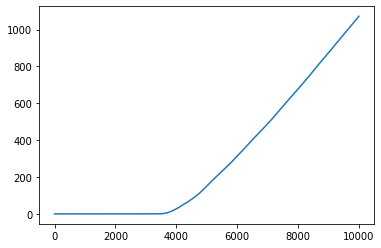

In [7]:
plt.plot(df_temp["Distance"], df_temp["Altitude_Above_Ground"])

# Failure Test

In [7]:
df_temp = pd.read_csv("E:\Work\Doing\B737-800-CFM56-7B24\Data\last_failed.csv")

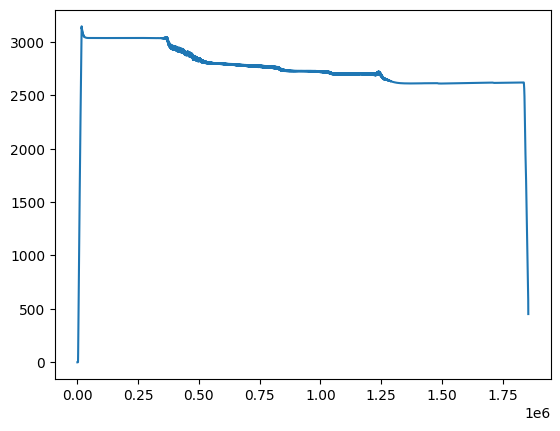

In [8]:
plt.plot(df_temp["Distance"], df_temp["Altitude_Above_Ground"])

In [6]:
df_temp.iloc[-30:][["Altitude_Above_Ground", "ROC"]]

,Altitude_Above_Ground,ROC
1333,1083.305199,-21366.203125
1334,1046.630539,-21599.996094
1335,1007.631718,-21832.310547
1336,970.132843,-22038.632812
1337,932.918719,-22226.855469
1338,874.583888,-22488.718750
1339,837.565204,-22633.191406
1340,800.058871,-22762.515625
1341,762.052321,-22875.839844
1342,724.942575,-22968.925781


# Automatized Calibration

In [88]:
import math
import numpy as np
import copy
import pandas as pd
import sys
import time

def rudder_calibration_TO(myflight, states_p, states_d, states_i, Kp, Kd, Ki, Err, plot_flag=True):
    E = [Err, Err]
    count_total = len(states_p)*len(states_d)*len(states_i)
    count = 0
    myflight.client.sendDREF("sim/time/sim_speed", 20)
    for kp in states_p:
        for kd in states_d:
            inner_counter = 0
            for ki in states_i:
                count += 1
                inner_counter += 1
                print("-------------------------------------------------------")
                print("take off rudder calibration test #{:g} out of {:g}".format(count, count_total))
                print("kp: {:.5f}, kd: {:.5f}, ki: {:.5f}".format(kp, kd, ki))
                print("Best parameters so far:")
                print("kp: {:.5f}, kd: {:.5f}, ki: {:.5f}".format(Kp, Kd, Ki))
                print("Best error so far: {:.3f}".format(Err))
                if kp<kd:
                    continue
                if kp<=ki:
                    continue
                # if kd<=ki:
                #     continue

                myflight.params_general = params
                myflight.update()
                myflight.get_params()
                myflight.params.loc[0, 'rudder_kp_to'] = kp
                myflight.params.loc[0, 'rudder_kd_to'] = kd
                myflight.params.loc[0, 'rudder_ki_to'] = ki
                myflight.get_velocities_dep()
                
                myflight.take_off()
                
                if plot_flag:
                    plt.figure()
                    plt.subplot(1,2,1)
                    plt.plot(myflight.df["Time"], myflight.df["Heading"])
                    plt.subplot(1,2,2)
                    plt.plot(myflight.df["Time"], myflight.df["Rudder"])
                    plt.show()

                if myflight.is_ok != 0:
                    err = myflight.Err_psi
                else:
                    err = sys.maxsize/myflight.df.iloc[-1]["Time"]

                print("Error: ", err)
                E.append(err)
                myflight.reset()
                print(len(myflight.df))
                if (err < Err):
                    Err = err
                    Kp = kp
                    Kd = kd
                    Ki = ki

                if (err>E[-2]) and (inner_counter>1):
                    count += len(states_i) - inner_counter 
                    break
        if Kp<kp:
            break
    myflight.reset()
    myflight.client.sendDREF("sim/time/sim_speed", 0)
    return Kp, Kd, Ki, Err

def elevator_calibration_C1(myflight, states_p, states_d, states_i,Kp,Kd,Ki,Err, plot_flag=True, point=None):

    E = [Err, Err]
    count_total = len(states_p)*len(states_d)*len(states_i)
    count = 0
    myflight.client.sendDREF("sim/time/sim_speed", 20)
    for kp in states_p:
        for kd in states_d:
            inner_counter = 0
            for ki in states_i:
                inner_counter += 1
                count += 1
                print("-------------------------------------------------------")
                print("climb 1 elevator calibration test #{:g} out of {:g}".format(count, count_total))
                print("kp: {:.5f}, kd: {:.5f}, ki: {:.5f}".format(kp, kd, ki))
                print("Best parameters so far:")
                print("kp: {:.5f}, kd: {:.5f}, ki: {:.5f}".format(Kp, Kd, Ki))
                print("Best error so far: {:.3f}".format(Err))
                # if kp<kd:
                #     continue
                if kp<=ki:
                    continue
                if kd<=ki:
                    continue
                
                myflight.reset(point=point)
                myflight.update()
                myflight.params.loc[0, 'elevator_kp_cc1'] = kp
                myflight.params.loc[0, 'elevator_kd_cc1'] = kd
                myflight.params.loc[0, 'elevator_ki_cc1'] = ki
                myflight.get_velocities_dep()
                myflight.get_velocities_app()
                if point==None:
                    myflight.take_off()
                myflight.climb_cc_1(END_ALT=1500, pause=1)
                if plot_flag:
                    plt.figure(figsize=(12,6))

                    plt.subplot(3,1,1)
                    plt.plot(myflight.df.iloc[100:]["Time"], myflight.df.iloc[100:]["vpath"])
                    plt.grid(True)
                    
                    plt.subplot(3,1,2)
                    plt.plot(myflight.df.iloc[100:]["Time"], myflight.df.iloc[100:]["Elevator"])
                    plt.grid(True)
                    
                    plt.subplot(3,1,3)
                    plt.plot(myflight.df.iloc[100:]["Time"], myflight.df.iloc[100:]["CAS"])
                    plt.axhline(y=myflight.velocities_dep["V2"][0]+15, color='r', linestyle='--')
                    plt.grid(True)
                    
                    plt.show()

                if myflight.is_ok != 0:
                    err = myflight.Err_vpath
                else:
                    err = sys.maxsize/myflight.df.iloc[-1]["Time"]

                print("Error: ", err)
                E.append(err)
                if (err < Err):
                    Err = err
                    Kp = kp
                    Kd = kd
                    Ki = ki

                if (err>E[-2]) and (inner_counter>1):
                    count += len(states_i) - inner_counter 
                    break
        if Kp<kp:
            break
    myflight.reset()
    myflight.client.sendDREF("sim/time/sim_speed", 0)
    return Kp, Kd, Ki, Err

def aileron_calibration_C1(myflight, states_p, states_d, states_i,Kp,Kd,Ki,Err, plot_flag=True, point=None):

    E = [Err, Err]
    count_total = len(states_p)*len(states_d)*len(states_i)
    count = 0
    myflight.client.sendDREF("sim/time/sim_speed", 6)
    for kp in states_p:
        for kd in states_d:
            inner_counter = 0
            for ki in states_i:
                
                inner_counter += 1
                count += 1
                print("-------------------------------------------------------")
                print("climb 1 aileron calibration test #{:g} out of {:g}".format(count, count_total))
                print("kp: {:.5f}, kd: {:.5f}, ki: {:.5f}".format(kp, kd, ki))
                print("Best parameters so far:")
                print("kp: {:.5f}, kd: {:.5f}, ki: {:.5f}".format(Kp, Kd, Ki))
                print("Best error so far: {:.3f}".format(Err))
                if kp<kd:
                    continue
                if kp<=ki:
                    continue
                if kd<=ki:
                    continue
                
                myflight.reset(point=point)
                myflight.update()
                myflight.params.loc[0, 'aileron_kp_cc1'] = kp
                myflight.params.loc[0, 'aileron_kd_cc1'] = kd
                myflight.params.loc[0, 'aileron_ki_cc1'] = ki
                myflight.get_velocities_dep()
                myflight.get_velocities_app()
                myflight.climb_cc_1(END_ALT=1500, Bank_Angle=15, Bank_Duration=20)
                if plot_flag:
                    plt.figure()
                    plt.subplot(1,2,1)
                    plt.plot(myflight.df["Time"], myflight.df["Roll"])
                    plt.subplot(1,2,2)
                    plt.plot(myflight.df["Time"], myflight.df["Aileron"])
                    plt.show()

                if myflight.is_ok != 0:
                    err = myflight.Err_roll
                else:
                    err = sys.maxsize/myflight.df.iloc[-1]["Time"]

                print("Error: ", err)
                E.append(err)
                if (err < Err):
                    Err = err
                    Kp = kp
                    Kd = kd
                    Ki = ki

                if (err>E[-2]) and (inner_counter>1):
                    count += len(states_i) - inner_counter 
                    break
        if Kp<kp:
            break
    myflight.reset()
    myflight.client.sendDREF("sim/time/sim_speed", 0)
    return Kp, Kd, Ki, Err  

def throttle_calibration_lvl(myflight, states_p, states_d, states_i,Kp,Kd,Ki,Err, plot_flag=True, point=None):
    
    E = [Err, Err]
    count_total = len(states_p)*len(states_d)*len(states_i)
    count = 0
    myflight.client.sendDREF("sim/time/sim_speed", 20)
    for kp in states_p:
        for kd in states_d:
            inner_counter = 0
            for ki in states_i:
                inner_counter += 1
                count += 1
                print("-------------------------------------------------------")
                print("level throttle calibration test #{:g} out of {:g}".format(count, count_total))
                print("kp: {:.5f}, kd: {:.5f}, ki: {:.5f}".format(kp, kd, ki))
                print("Best parameters so far:")
                print("kp: {:.5f}, kd: {:.5f}, ki: {:.5f}".format(Kp, Kd, Ki))
                print("Best error so far: {:.3f}".format(Err))
                # if kp<kd:
                #     continue
                if kp<=ki:
                    continue
                if kd<=ki:
                    continue
                
                myflight.reset(point=point)
                myflight.params.loc[0, 'throttle_kp_lvl'] = kp
                myflight.params.loc[0, 'throttle_kd_lvl'] = kd
                myflight.params.loc[0, 'throttle_ki_lvl'] = ki
                myflight.update()
                myflight.get_velocities_dep()
                myflight.get_velocities_app()
                myflight.level_slow(END_DIST=20000)
                if plot_flag:
                    plt.figure()
                    plt.subplot(1,3,1)
                    plt.plot(myflight.df["Distance"], myflight.df["Altitude_Above_Ground"])
                    plt.subplot(1,3,2)
                    plt.plot(myflight.df["Distance"], myflight.df["CAS"])
                    plt.subplot(1,3,3)
                    plt.plot(myflight.df["Time"], myflight.df["Throttle"])
                    plt.show()

                if myflight.is_ok != 0:
                    err = myflight.Err_lvl
                else:
                    err = sys.maxsize/myflight.df.iloc[-1]["Time"]

                print("Error: ", err)
                E.append(err)
                if (err < Err):
                    Err = err
                    Kp = kp
                    Kd = kd
                    Ki = ki

                if (err>E[-2]) and (inner_counter>1):
                    count += len(states_i) - inner_counter 
                    break
        if Kp<kp:
            break
    myflight.reset()
    myflight.client.sendDREF("sim/time/sim_speed", 0)
    return Kp, Kd, Ki, Err
    
def elevator_calibration_CA(myflight, states_p, states_d, states_i,Kp,Kd,Ki,Err, plot_flag=True, point=None):

    E = [Err, Err]
    count_total = len(states_p)*len(states_d)*len(states_i)
    count = 0
    myflight.client.sendDREF("sim/time/sim_speed", 6)
    for kp in states_p:
        for kd in states_d:
            inner_counter = 0
            for ki in states_i:
                inner_counter += 1
                count += 1
                print("-------------------------------------------------------")
                print("acceleration elevator calibration test #{:g} out of {:g}".format(count, count_total))
                print("kp: {:.5f}, kd: {:.5f}, ki: {:.5f}".format(kp, kd, ki))
                print("Best parameters so far:")
                print("kp: {:.5f}, kd: {:.5f}, ki: {:.5f}".format(Kp, Kd, Ki))
                print("Best error so far: {:.3f}".format(Err))
                if kp<kd:
                    continue
                if kp<=ki:
                    continue
                if kd<=ki:
                    continue
                
                myflight.reset(point=point)
                myflight.update()
                myflight.params.loc[0, 'elevator_kp_ca'] = kp
                myflight.params.loc[0, 'elevator_kd_ca'] = kd
                myflight.params.loc[0, 'elevator_ki_ca'] = ki
                myflight.get_velocities_dep()
                myflight.get_velocities_app()
                myflight.climb_ca()
                if plot_flag:
                    plt.figure()
                    plt.subplot(1,2,1)
                    plt.plot(myflight.df["Time"], myflight.df["vpath"])
                    plt.subplot(1,2,2)
                    plt.plot(myflight.df["Time"], myflight.df["Elevator"])
                    plt.show()

                if myflight.is_ok != 0:
                    err = myflight.Err_vpath
                else:
                    err = sys.maxsize/myflight.df.iloc[-1]["Time"]

                print("Error: ", err)
                E.append(err)
                if (err < Err):
                    Err = err
                    Kp = kp
                    Kd = kd
                    Ki = ki

                if (err>E[-2]) and (inner_counter>1):
                    count += len(states_i) - inner_counter 
                    break
        if Kp<kp:
            break
    myflight.reset()
    myflight.client.sendDREF("sim/time/sim_speed", 0)
    return Kp, Kd, Ki, Err
    
def aileron_calibration_CA(myflight, states_p, states_d, states_i,Kp,Kd,Ki,Err, plot_flag=True, point=None):
    
    E = [Err, Err]
    count_total = len(states_p)*len(states_d)*len(states_i)
    count = 0
    myflight.client.sendDREF("sim/time/sim_speed", 20)
    for kp in states_p:
        for kd in states_d:
            inner_counter = 0
            for ki in states_i:
                inner_counter += 1
                count += 1
                print("-------------------------------------------------------")
                print("acceleration aileron calibration test #{:g} out of {:g}".format(count, count_total))
                print("kp: {:.5f}, kd: {:.5f}, ki: {:.5f}".format(kp, kd, ki))
                print("Best parameters so far:")
                print("kp: {:.5f}, kd: {:.5f}, ki: {:.5f}".format(Kp, Kd, Ki))
                print("Best error so far: {:.3f}".format(Err))
                if kp<kd:
                    continue
                if kp<=ki:
                    continue
                if kd<=ki:
                    continue
                
                myflight.reset(point=point)
                myflight.update()
                myflight.params.loc[0, 'aileron_kp_ca'] = kp
                myflight.params.loc[0, 'aileron_kd_ca'] = kd
                myflight.params.loc[0, 'aileron_ki_ca'] = ki
                myflight.get_velocities_dep()
                myflight.get_velocities_app()
                myflight.climb_ca(Bank_Angle=15, Bank_Duration=20)
                if plot_flag:
                    plt.figure()
                    plt.subplot(1,2,1)
                    plt.plot(myflight.df["Time"], myflight.df["Roll"])
                    plt.subplot(1,2,2)
                    plt.plot(myflight.df["Time"], myflight.df["Aileron"])
                    plt.show()

                if myflight.is_ok != 0:
                    err = myflight.Err_roll
                else:
                    err = sys.maxsize/myflight.df.iloc[-1]["Time"]

                print("Error: ", err)
                E.append(err)
                if (err < Err):
                    Err = err
                    Kp = kp
                    Kd = kd
                    Ki = ki

                if (err>E[-2]) and (inner_counter>1):
                    count += len(states_i) - inner_counter 
                    break
        if Kp<kp:
            break
    myflight.reset()
    myflight.client.sendDREF("sim/time/sim_speed", 0)
    return Kp, Kd, Ki, Err

def elevator_calibration_CC2(myflight, states_p, states_d, states_i,Kp,Kd,Ki,Err, plot_flag=True, point=None):

    alt_start = point["df"].iloc[-1]["Altitude_Above_Ground"]
    E = [Err, Err]
    count_total = len(states_p)*len(states_d)*len(states_i)
    count = 0
    myflight.client.sendDREF("sim/time/sim_speed", 6)
    for kp in states_p:
        for kd in states_d:
            inner_counter = 0
            for ki in states_i:
                inner_counter += 1
                count += 1
                print("-------------------------------------------------------")
                print("climb 2 elevator calibration test #{:g} out of {:g}".format(count, count_total))
                print("kp: {:.5f}, kd: {:.5f}, ki: {:.5f}".format(kp, kd, ki))
                print("Best parameters so far:")
                print("kp: {:.5f}, kd: {:.5f}, ki: {:.5f}".format(Kp, Kd, Ki))
                print("Best error so far: {:.3f}".format(Err))
                if kp<kd:
                    continue
                if kp<=ki:
                    continue
                if kd<=ki:
                    continue
                
                myflight.reset(point=point)
                myflight.update()
                myflight.params.loc[0, 'elevator_kp_cc2'] = kp
                myflight.params.loc[0, 'elevator_kd_cc2'] = kd
                myflight.params.loc[0, 'elevator_ki_cc2'] = ki
                myflight.get_velocities_dep()
                myflight.get_velocities_app()
                myflight.climb_cc_2(END_ALT=alt_start+3000)
                if plot_flag:
                    plt.figure()
                    plt.subplot(1,2,1)
                    plt.plot(myflight.df["Time"], myflight.df["vpath"])
                    plt.subplot(1,2,2)
                    plt.plot(myflight.df["Time"], myflight.df["Elevator"])
                    plt.show()

                if myflight.is_ok != 0:
                    err = myflight.Err_vpath
                else:
                    err = sys.maxsize/myflight.df.iloc[-1]["Time"]

                print("Error: ", err)
                E.append(err)
                if (err < Err):
                    Err = err
                    Kp = kp
                    Kd = kd
                    Ki = ki

                if (err>E[-2]) and (inner_counter>1):
                    count += len(states_i) - inner_counter 
                    break
        if Kp<kp:
            break
    myflight.reset()
    myflight.client.sendDREF("sim/time/sim_speed", 0)
    return Kp, Kd, Ki, Err

def aileron_calibration_CC2(myflight, states_p, states_d, states_i,Kp,Kd,Ki,Err, plot_flag=True, point=None):

    alt_start = point["df"].iloc[-1]["Altitude_Above_Ground"]
    E = [Err, Err]
    count_total = len(states_p)*len(states_d)*len(states_i)
    count = 0
    myflight.client.sendDREF("sim/time/sim_speed", 20)
    for kp in states_p:
        for kd in states_d:
            inner_counter = 0
            for ki in states_i:
                inner_counter += 1
                count += 1
                print("-------------------------------------------------------")
                print("climb 2 aileron calibration test #{:g} out of {:g}".format(count, count_total))
                print("kp: {:.5f}, kd: {:.5f}, ki: {:.5f}".format(kp, kd, ki))
                print("Best parameters so far:")
                print("kp: {:.5f}, kd: {:.5f}, ki: {:.5f}".format(Kp, Kd, Ki))
                print("Best error so far: {:.3f}".format(Err))
                if kp<kd:
                    continue
                if kp<=ki:
                    continue
                if kd<=ki:
                    continue
                
                myflight.reset(point=point)
                myflight.update()
                myflight.params.loc[0, 'aileron_kp_cc2'] = kp
                myflight.params.loc[0, 'aileron_kd_cc2'] = kd
                myflight.params.loc[0, 'aileron_ki_cc2'] = ki
                myflight.get_velocities_dep()
                myflight.get_velocities_app()
                myflight.climb_cc_2(END_ALT=alt_start+3000, Bank_Angle=15, Bank_Duration=20)
                if plot_flag:
                    plt.figure()
                    plt.subplot(1,2,1)
                    plt.plot(myflight.df["Time"], myflight.df["Roll"])
                    plt.subplot(1,2,2)
                    plt.plot(myflight.df["Time"], myflight.df["Aileron"])
                    plt.show()

                if myflight.is_ok != 0:
                    err = myflight.Err_roll
                else:
                    err = sys.maxsize/myflight.df.iloc[-1]["Time"]

                print("Error: ", err)
                E.append(err)
                if (err < Err):
                    Err = err
                    Kp = kp
                    Kd = kd
                    Ki = ki

                if (err>E[-2]) and (inner_counter>1):
                    count += len(states_i) - inner_counter 
                    break
        if Kp<kp:
            break
    myflight.reset()
    myflight.client.sendDREF("sim/time/sim_speed", 0)
    return Kp, Kd, Ki, Err

def throttle_calibration_D2(myflight, states_p, states_d, states_i,Kp,Kd,Ki,Err, plot_flag=True, point=None):

    E = [Err, Err]
    count_total = len(states_p)*len(states_d)*len(states_i)
    count = 0
    myflight.client.sendDREF("sim/time/sim_speed", 20)
    for kp in states_p:
        for kd in states_d:
            inner_counter = 0
            for ki in states_i:
                inner_counter += 1
                count += 1
                print("-------------------------------------------------------")
                print("Descent 2 throttle calibration test #{:g} out of {:g}".format(count, count_total))
                print("kp: {:.5f}, kd: {:.5f}, ki: {:.5f}".format(kp, kd, ki))
                print("Best parameters so far:")
                print("kp: {:.5f}, kd: {:.5f}, ki: {:.5f}".format(Kp, Kd, Ki))
                print("Best error so far: {:.3f}".format(Err))
                # if kp<kd:
                #     continue
                if kp<=ki:
                    continue
                if kd<=ki:
                    continue
                
                myflight.reset(point=point)
                Vref = myflight.df.iloc[-1]["CAS"]
                myflight.update()
                myflight.params.loc[0, 'throttle_kp_d2'] = kp
                myflight.params.loc[0, 'throttle_kd_d2'] = kd
                myflight.params.loc[0, 'throttle_ki_d2'] = ki
                myflight.get_velocities_dep()
                myflight.get_velocities_app()
                
                myflight.descend_2()
                if plot_flag:
                    plt.figure()
                    plt.subplot(1,3,1)
                    plt.plot(myflight.df["Time"], myflight.df["Throttle"])
                    plt.subplot(1,3,2)
                    plt.plot(myflight.df["Time"], myflight.df["vpath"])
                    plt.axhline(y = -3, color = 'r', linestyle = '--')
                    plt.subplot(1,3,3)
                    plt.plot(myflight.df["Time"], myflight.df["CAS"])
                    plt.axhline(y = Vref, color = 'r', linestyle = '--')
                    plt.show()

                if myflight.is_ok != 0:
                    err = myflight.Err_d2
                else:
                    err = sys.maxsize/myflight.df.iloc[-1]["Time"]

                print("Error: ", err)
                E.append(err)
                if (err < Err):
                    Err = err
                    Kp = kp
                    Kd = kd
                    Ki = ki

                if (err>E[-2]) and (inner_counter>1):
                    count += len(states_i) - inner_counter 
                    break
        if Kp<kp:
            break
    myflight.reset()
    myflight.client.sendDREF("sim/time/sim_speed", 0)
    return Kp, Kd, Ki, Err

def two_round_calibration(cal_fn, myflight, coarse_states_p, coarse_states_d, coarse_states_i, **kwargs):
    """
    Runs a coarse search, then a fine search centered on the best result.
    Always returns the globally best (Kp, Kd, Ki, Err) across both rounds.
    """
    # Round 1: coarse search
    kp1, kd1, ki1, err1 = cal_fn(
        myflight=myflight,
        states_p=coarse_states_p,
        states_d=coarse_states_d,
        states_i=coarse_states_i,
        Kp=0, Kd=0, Ki=0,
        Err=sys.maxsize,
        **kwargs
    )

    if kp1 == 0 and kd1 == 0 and ki1 == 0:
        print("WARNING: coarse search found no improvement, skipping fine search.")
        return kp1, kd1, ki1, err1

    # Round 2: fine search centered on best coarse result
    fine_p = np.linspace(kp1 - kp1 / 3, kp1 + kp1 / 3, 5)
    fine_d = np.linspace(kd1 - kd1 / 3, kd1 + kd1 / 3, 5)
    fine_i = np.linspace(ki1 - ki1 / 3, ki1 + ki1 / 3, 5)

    kp2, kd2, ki2, err2 = cal_fn(
        myflight=myflight,
        states_p=fine_p,
        states_d=fine_d,
        states_i=fine_i,
        Kp=kp1, Kd=kd1, Ki=ki1,   # seed with coarse best
        Err=err1,                   # ← key fix: fine search must BEAT the coarse best
        **kwargs
    )

    # Return whichever round actually produced the best result
    if err2 < err1:
        return kp2, kd2, ki2, err2
    else:
        return kp1, kd1, ki1, err1
    
def automatized_calibration(myflight, weight_min_dep, weight_max_dep, params_dir, climb_1_elevator=True, climb_1_aileron=True, lvl_throttle=True, acc_elevator=True, acc_aileron=True, climb_2_elevator=True, climb_2_aileron=True, descend_2_throttle=True):
    weight_min = weight_min_dep
    weight_max = weight_max_dep
    params = pd.read_csv(params_dir)
    params.loc[0, "Weight"] = weight_min
    params.loc[1, "Weight"] = weight_max

    if climb_1_elevator:

        # creating reset points
        myflight.friction_n = 0
        myflight.set_weight(weight_min)
        myflight.set_wind(wind_speed=0, wind_dir=0)
        params.loc[0, 'elevator_to'] = 0.25
        params.loc[1, 'elevator_to'] = 0.3
        myflight.params_general = params
        myflight.get_params()
        myflight.get_velocities_dep()
        myflight.get_velocities_app()
        myflight.take_off(pause=True)
        myflight.client.sendDREF("sim/time/sim_speed", 0)
        point_climb_0 = myflight.get_point_data()
        myflight.reset()
        myflight.client.sendDREF("sim/time/sim_speed", 20)

        myflight.set_weight(weight_max)
        myflight.set_wind(wind_speed=0, wind_dir=0)
        myflight.params_general = params
        myflight.get_params()
        myflight.get_velocities_dep()
        myflight.get_velocities_app()
        myflight.take_off(pause=True)
        myflight.client.sendDREF("sim/time/sim_speed", 0)
        point_climb_1 = myflight.get_point_data()
        myflight.reset()
        myflight.client.sendDREF("sim/time/sim_speed", 20)

        point_climb_0["df"].loc[point_climb_0["df"]["Time"] < 15, "vpath"] = 0
        point_climb_1["df"].loc[point_climb_1["df"]["Time"] < 15, "vpath"] = 0
        point_climb_0["df"]["Roll"] = 0
        point_climb_1["df"]["Roll"] = 0

        # initializing params
        params_dir = "Controls/params.csv"

        params.loc[0, 'vpath_tc_cc1'] = 2.0
        params.loc[1, 'vpath_tc_cc1'] = 2.0
        params.loc[0, 'elevator_kp_cc1'] = 0.0
        params.loc[0, 'elevator_kd_cc1'] = 0.0
        params.loc[0, 'elevator_ki_cc1'] = 0.0
        params.loc[1, 'elevator_kp_cc1'] = 0.0
        params.loc[1, 'elevator_kd_cc1'] = 0.0
        params.loc[1, 'elevator_ki_cc1'] = 0.0
        params.loc[0, "roll_tc_cc1"] = 1.0
        params.loc[1, "roll_tc_cc1"] = 1.0

        # maximum weight calibration
        coarse_states_p = np.array([0.0035, 0.0045, 0.0055])
        coarse_states_d = np.array([0.004, 0.005, 0.006])
        coarse_states_i = np.array([0.00005, 0.00007, 0.0001])

        myflight.client.sendDREF("sim/time/sim_speed", 6)
        time.sleep(2)
        myflight.friction_n = 0
        myflight.set_weight(weight_max)
        myflight.set_wind(wind_speed=0, wind_dir=0)
        myflight.params_general = params
        myflight.get_params()

        KP_rt, KD_rt, KI_rt, Err = two_round_calibration(
            cal_fn=elevator_calibration_C1,
            myflight=myflight,
            coarse_states_p=coarse_states_p,
            coarse_states_d=coarse_states_d,
            coarse_states_i=coarse_states_i,
            plot_flag=True,
            point=point_climb_1
        )
        params.loc[1, 'elevator_kp_cc1'] = copy.copy(KP_rt)
        params.loc[1, 'elevator_kd_cc1'] = copy.copy(KD_rt)
        params.loc[1, 'elevator_ki_cc1'] = copy.copy(KI_rt)

        # minimum weight calibration
        cmd_lst = [0, 0, 0, 1, 1, 0, 0]
        myflight.client.sendDREF("sim/time/sim_speed", 20)
        myflight.client.sendCTRL(cmd_lst)
        time.sleep(2)
        myflight.friction_n = 0
        myflight.set_weight(weight_min)
        myflight.set_wind(wind_speed=0, wind_dir=0)
        myflight.params_general = params
        myflight.get_params()

        fine_states_p = np.linspace(KP_rt - KP_rt / 3.5, KP_rt + KP_rt / 4, 5)
        fine_states_d = np.linspace(KD_rt - KD_rt / 3.5, KD_rt + KD_rt / 4, 5)
        fine_states_i = np.linspace(KI_rt - KI_rt / 3.5, KI_rt + KI_rt / 4, 5)

        KP_rt, KD_rt, KI_rt, Err = two_round_calibration(
            cal_fn=elevator_calibration_C1,
            myflight=myflight,
            coarse_states_p=fine_states_p,
            coarse_states_d=fine_states_d,
            coarse_states_i=fine_states_i,
            plot_flag=True,
            point=point_climb_0
        )
        params.loc[0, 'elevator_kp_cc1'] = copy.copy(KP_rt)
        params.loc[0, 'elevator_kd_cc1'] = copy.copy(KD_rt)
        params.loc[0, 'elevator_ki_cc1'] = copy.copy(KI_rt)

        params.to_csv(params_dir, index=False)

    if climb_1_aileron:

        # initialize params and get reset points
        if not climb_1_elevator:
            params.loc[0, 'aileron_kp_cc1'] = 0.0
            params.loc[0, 'aileron_kd_cc1'] = 0.0
            params.loc[0, 'aileron_ki_cc1'] = 0.0
            params.loc[1, 'aileron_kp_cc1'] = 0.0
            params.loc[1, 'aileron_kd_cc1'] = 0.0
            params.loc[1, 'aileron_ki_cc1'] = 0.0
            params.loc[0, "roll_tc_cc1"] = 1.0
            params.loc[1, "roll_tc_cc1"] = 1.0

            # creating reset points
            myflight.friction_n = 0
            myflight.client.sendDREF("sim/time/sim_speed", 20)
            myflight.set_weight(weight_min)
            myflight.set_wind(wind_speed=0, wind_dir=0)
            myflight.get_velocities_dep()
            myflight.get_velocities_app()
            myflight.params_general = params
            myflight.get_params()
            myflight.take_off()
            myflight.client.sendDREF("sim/time/sim_speed", 0)
            point_climb_0 = myflight.get_point_data()
            myflight.reset()
            myflight.client.sendDREF("sim/time/sim_speed", 20)

            myflight.client.sendDREF("sim/time/sim_speed", 20)
            myflight.set_weight(weight_max)
            myflight.set_wind(wind_speed=0, wind_dir=0)
            myflight.get_velocities_dep()
            myflight.get_velocities_app()
            myflight.params_general = params
            myflight.get_params()
            myflight.take_off()
            myflight.client.sendDREF("sim/time/sim_speed", 0)
            point_climb_1 = myflight.get_point_data()
            myflight.reset()
            myflight.client.sendDREF("sim/time/sim_speed", 20)

            point_climb_0["df"].loc[point_climb_0["df"]["Time"] < 15, "vpath"] = 0
            point_climb_1["df"].loc[point_climb_1["df"]["Time"] < 15, "vpath"] = 0
            point_climb_0["df"]["Roll"] = 0
            point_climb_1["df"]["Roll"] = 0

        # maximum weight calibration
        coarse_states_p = np.array([0.05, 0.1, 0.17])
        coarse_states_d = np.array([0.05, 0.1, 0.17])
        coarse_states_i = np.array([0.005, 0.01, 0.017])

        myflight.friction_n = 0
        myflight.client.sendDREF("sim/time/sim_speed", 20)
        myflight.set_weight(weight_max)
        myflight.set_wind(wind_speed=0, wind_dir=0)
        myflight.params_general = params
        myflight.get_params()

        KP_rt, KD_rt, KI_rt, Err = two_round_calibration(
            cal_fn=aileron_calibration_C1,
            myflight=myflight,
            coarse_states_p=coarse_states_p,
            coarse_states_d=coarse_states_d,
            coarse_states_i=coarse_states_i,
            plot_flag=True,
            point=point_climb_1
        )
        params.loc[1, 'aileron_kp_cc1'] = copy.copy(KP_rt)
        params.loc[1, 'aileron_kd_cc1'] = copy.copy(KD_rt)
        params.loc[1, 'aileron_ki_cc1'] = copy.copy(KI_rt)

        # minimum weight calibration
        cmd_lst = [0, 0, 0, 1, 1, 0, 0]
        myflight.client.sendCTRL(cmd_lst)
        time.sleep(2)
        myflight.friction_n = 0
        myflight.client.sendDREF("sim/time/sim_speed", 20)
        myflight.set_weight(weight_min)
        myflight.set_wind(wind_speed=0, wind_dir=0)
        myflight.params_general = params
        myflight.get_params()

        fine_states_p = np.linspace(KP_rt - KP_rt / 2.5, KP_rt, 5)
        fine_states_d = np.linspace(KD_rt - KD_rt / 2.5, KD_rt, 5)
        fine_states_i = np.linspace(KI_rt - KI_rt / 2.5, KI_rt, 5)

        KP_rt, KD_rt, KI_rt, Err = two_round_calibration(
            cal_fn=aileron_calibration_C1,
            myflight=myflight,
            coarse_states_p=fine_states_p,
            coarse_states_d=fine_states_d,
            coarse_states_i=fine_states_i,
            plot_flag=True,
            point=point_climb_0
        )
        params.loc[0, 'aileron_kp_cc1'] = copy.copy(KP_rt)
        params.loc[0, 'aileron_kd_cc1'] = copy.copy(KD_rt)
        params.loc[0, 'aileron_ki_cc1'] = copy.copy(KI_rt)

        params.to_csv(params_dir, index=False)

    if lvl_throttle or acc_aileron or acc_elevator:
        check = 0
        while check == 0:
            myflight.client.sendDREF("sim/time/sim_speed", 20)
            myflight.friction_n = 0
            myflight.set_weight(weight_min)
            myflight.set_wind(wind_speed=0, wind_dir=0)
            myflight.get_velocities_dep()
            myflight.get_velocities_app()
            myflight.params_general = params
            myflight.get_params()
            myflight.take_off()
            myflight.climb_cc_1(pause=True)
            myflight.client.sendDREF("sim/time/sim_speed", 0)
            point_acc_0 = myflight.get_point_data()
            ok_1 = myflight.is_ok
            myflight.reset()
            myflight.client.sendDREF("sim/time/sim_speed", 20)
            if ok_1:
                check = 1

        check = 0
        while check == 0:
            myflight.set_weight(weight_max)
            myflight.set_wind(wind_speed=0, wind_dir=0)
            myflight.get_velocities_dep()
            myflight.get_velocities_app()
            myflight.params_general = params
            myflight.get_params()
            myflight.take_off()
            myflight.climb_cc_1(pause=True)
            myflight.client.sendDREF("sim/time/sim_speed", 0)
            point_acc_1 = myflight.get_point_data()
            ok_2 = myflight.is_ok
            myflight.reset()
            myflight.client.sendDREF("sim/time/sim_speed", 20)
            if ok_2:
                check = 1

        point_acc_0["df"].loc[point_acc_0["df"]["Time"] < 15, "vpath"] = 0
        point_acc_1["df"].loc[point_acc_1["df"]["Time"] < 15, "vpath"] = 0
        point_acc_0["df"].loc[point_acc_0["df"]["Time"] < 15, "Roll"] = 0
        point_acc_1["df"].loc[point_acc_1["df"]["Time"] < 15, "Roll"] = 0

    if lvl_throttle:

        # initializing params
        params.loc[0, 'throttle_kp_lvl'] = 0.0
        params.loc[0, 'throttle_kd_lvl'] = 0.0
        params.loc[0, 'throttle_ki_lvl'] = 0.0
        params.loc[1, 'throttle_kp_lvl'] = 0.0
        params.loc[1, 'throttle_kd_lvl'] = 0.0
        params.loc[1, 'throttle_ki_lvl'] = 0.0

        # maximum weight calibration
        coarse_states_p = np.array([0.1, 0.15, 0.25, 0.4, 0.7])
        coarse_states_d = np.array([0.2, 0.4, 0.6, 0.8, 1.1])
        coarse_states_i = np.array([0.01, 0.015, 0.02])

        cmd_lst = [0, 0, 0, 1, 1, 0, 0]
        myflight.client.sendDREF("sim/time/sim_speed", 20)
        myflight.client.sendCTRL(cmd_lst)
        time.sleep(2)
        myflight.friction_n = 0
        myflight.set_weight(weight_max)
        myflight.set_wind(wind_speed=0, wind_dir=0)
        myflight.params_general = params
        myflight.get_params()

        KP_rt, KD_rt, KI_rt, Err = two_round_calibration(
            cal_fn=throttle_calibration_lvl,
            myflight=myflight,
            coarse_states_p=coarse_states_p,
            coarse_states_d=coarse_states_d,
            coarse_states_i=coarse_states_i,
            plot_flag=True,
            point=point_acc_1
        )
        params.loc[1, 'throttle_kp_lvl'] = copy.copy(KP_rt)
        params.loc[1, 'throttle_kd_lvl'] = copy.copy(KD_rt)
        params.loc[1, 'throttle_ki_lvl'] = copy.copy(KI_rt)

        # minimum weight calibration
        cmd_lst = [0, 0, 0, 1, 1, 0, 0]
        myflight.client.sendDREF("sim/time/sim_speed", 20)
        myflight.client.sendCTRL(cmd_lst)
        time.sleep(2)
        myflight.friction_n = 0
        myflight.set_weight(weight_min)
        myflight.set_wind(wind_speed=0, wind_dir=0)
        myflight.params_general = params
        myflight.get_params()

        fine_states_p = np.linspace(KP_rt - KP_rt / 2, KP_rt + KP_rt / 2, 5)
        fine_states_d = np.linspace(KD_rt - KD_rt / 2, KD_rt + KD_rt / 2, 5)
        fine_states_i = np.array([0])

        KP_rt, KD_rt, KI_rt, Err = two_round_calibration(
            cal_fn=throttle_calibration_lvl,
            myflight=myflight,
            coarse_states_p=fine_states_p,
            coarse_states_d=fine_states_d,
            coarse_states_i=fine_states_i,
            plot_flag=True,
            point=point_acc_0
        )
        params.loc[0, 'throttle_kp_lvl'] = copy.copy(KP_rt)
        params.loc[0, 'throttle_kd_lvl'] = copy.copy(KD_rt)
        params.loc[0, 'throttle_ki_lvl'] = copy.copy(KI_rt)

        params.to_csv(params_dir, index=False)

    if acc_elevator:

        # initializing params
        params.loc[0, 'vpath_tc_ca'] = 2.0
        params.loc[1, 'vpath_tc_ca'] = 2.0
        params.loc[0, 'elevator_kp_ca'] = 0.0
        params.loc[0, 'elevator_kd_ca'] = 0.0
        params.loc[0, 'elevator_ki_ca'] = 0.0
        params.loc[1, 'elevator_kp_ca'] = 0.0
        params.loc[1, 'elevator_kd_ca'] = 0.0
        params.loc[1, 'elevator_ki_ca'] = 0.0

        # maximum weight calibration
        coarse_states_p = np.array([0.02, 0.035, 0.06])
        coarse_states_d = np.array([0.02, 0.035, 0.06])
        coarse_states_i = np.array([0.002, 0.0035, 0.006])

        cmd_lst = [0, 0, 0, 1, 1, 0, 0]
        myflight.client.sendDREF("sim/time/sim_speed", 20)
        myflight.client.sendCTRL(cmd_lst)
        time.sleep(2)
        myflight.friction_n = 0
        myflight.set_weight(weight_max)
        myflight.set_wind(wind_speed=0, wind_dir=0)
        myflight.params_general = params
        myflight.get_params()

        KP_rt, KD_rt, KI_rt, Err = two_round_calibration(
            cal_fn=elevator_calibration_CA,
            myflight=myflight,
            coarse_states_p=coarse_states_p,
            coarse_states_d=coarse_states_d,
            coarse_states_i=coarse_states_i,
            plot_flag=True,
            point=point_acc_1
        )
        params.loc[1, 'elevator_kp_ca'] = copy.copy(KP_rt)
        params.loc[1, 'elevator_kd_ca'] = copy.copy(KD_rt)
        params.loc[1, 'elevator_ki_ca'] = copy.copy(KI_rt)

        # minimum weight calibration
        cmd_lst = [0, 0, 0, 1, 1, 0, 0]
        myflight.client.sendDREF("sim/time/sim_speed", 20)
        myflight.client.sendCTRL(cmd_lst)
        time.sleep(2)
        myflight.friction_n = 0
        myflight.set_weight(weight_min)
        myflight.set_wind(wind_speed=0, wind_dir=0)
        myflight.params_general = params
        myflight.get_params()

        fine_states_p = np.linspace(KP_rt - KP_rt / 2.5, KP_rt, 5)
        fine_states_d = np.linspace(KD_rt - KD_rt / 2.5, KD_rt, 5)
        fine_states_i = np.linspace(KI_rt - KI_rt / 2.5, KI_rt, 5)

        KP_rt, KD_rt, KI_rt, Err = two_round_calibration(
            cal_fn=elevator_calibration_CA,
            myflight=myflight,
            coarse_states_p=fine_states_p,
            coarse_states_d=fine_states_d,
            coarse_states_i=fine_states_i,
            plot_flag=True,
            point=point_acc_0
        )
        params.loc[0, 'elevator_kp_ca'] = copy.copy(KP_rt)
        params.loc[0, 'elevator_kd_ca'] = copy.copy(KD_rt)
        params.loc[0, 'elevator_ki_ca'] = copy.copy(KI_rt)

        params.to_csv(params_dir, index=False)

    if acc_aileron:

        # initialize params
        if not acc_elevator:
            params.loc[0, 'aileron_kp_cc1'] = 0.0
            params.loc[0, 'aileron_kd_cc1'] = 0.0
            params.loc[0, 'aileron_ki_cc1'] = 0.0
            params.loc[1, 'aileron_kp_cc1'] = 0.0
            params.loc[1, 'aileron_kd_cc1'] = 0.0
            params.loc[1, 'aileron_ki_cc1'] = 0.0

        # maximum weight calibration
        coarse_states_p = np.array([0.02, 0.04, 0.08])
        coarse_states_d = np.array([0.02, 0.04, 0.08])
        coarse_states_i = np.array([0.001, 0.002, 0.004])

        myflight.friction_n = 0
        myflight.client.sendDREF("sim/time/sim_speed", 20)
        myflight.set_weight(weight_max)
        myflight.set_wind(wind_speed=0, wind_dir=0)
        myflight.params_general = params
        myflight.get_params()

        KP_rt, KD_rt, KI_rt, Err = two_round_calibration(
            cal_fn=aileron_calibration_CA,
            myflight=myflight,
            coarse_states_p=coarse_states_p,
            coarse_states_d=coarse_states_d,
            coarse_states_i=coarse_states_i,
            plot_flag=True,
            point=point_acc_1
        )
        params.loc[1, 'aileron_kp_ca'] = copy.copy(KP_rt)
        params.loc[1, 'aileron_kd_ca'] = copy.copy(KD_rt)
        params.loc[1, 'aileron_ki_ca'] = copy.copy(KI_rt)

        # minimum weight calibration
        myflight.friction_n = 0
        myflight.client.sendDREF("sim/time/sim_speed", 20)
        myflight.set_weight(weight_min)
        myflight.set_wind(wind_speed=0, wind_dir=0)
        myflight.params_general = params
        myflight.get_params()

        fine_states_p = np.linspace(KP_rt - KP_rt / 2.5, KP_rt, 5)
        fine_states_d = np.linspace(KD_rt - KD_rt / 2.5, KD_rt, 5)
        fine_states_i = np.linspace(KI_rt - KI_rt / 2.5, KI_rt, 5)

        KP_rt, KD_rt, KI_rt, Err = two_round_calibration(
            cal_fn=aileron_calibration_CA,
            myflight=myflight,
            coarse_states_p=fine_states_p,
            coarse_states_d=fine_states_d,
            coarse_states_i=fine_states_i,
            plot_flag=True,
            point=point_acc_0
        )
        params.loc[0, 'aileron_kp_ca'] = copy.copy(KP_rt)
        params.loc[0, 'aileron_kd_ca'] = copy.copy(KD_rt)
        params.loc[0, 'aileron_ki_ca'] = copy.copy(KI_rt)

        params.to_csv(params_dir, index=False)

    if climb_2_elevator or climb_2_aileron:
        check = 0
        while check == 0:
            myflight.friction_n = 0
            myflight.client.sendDREF("sim/time/sim_speed", 20)
            myflight.set_weight(weight_min)
            myflight.set_wind(wind_speed=0, wind_dir=0)
            myflight.get_velocities_dep()
            myflight.get_velocities_app()
            myflight.params_general = params
            myflight.get_params()
            myflight.take_off()
            myflight.climb_cc_1()
            myflight.climb_ca(END_CAS=250, pause=True)
            myflight.client.sendDREF("sim/time/sim_speed", 0)
            point_cc2_0 = myflight.get_point_data()
            ok_1 = myflight.is_ok
            myflight.reset()
            myflight.client.sendDREF("sim/time/sim_speed", 20)
            if ok_1:
                check = 1

        check = 0
        while check == 0:
            myflight.friction_n = 0
            myflight.set_weight(weight_max)
            myflight.set_wind(wind_speed=0, wind_dir=0)
            myflight.get_velocities_dep()
            myflight.get_velocities_app()
            myflight.params_general = params
            myflight.get_params()
            myflight.take_off()
            myflight.climb_cc_1()
            myflight.climb_ca(END_CAS=250, pause=True)
            myflight.client.sendDREF("sim/time/sim_speed", 0)
            point_cc2_1 = myflight.get_point_data()
            ok_2 = myflight.is_ok
            myflight.reset()
            myflight.client.sendDREF("sim/time/sim_speed", 20)
            if ok_2:
                check = 1

        point_cc2_0["df"].loc[point_cc2_0["df"]["Time"] < 15, "vpath"] = 0
        point_cc2_1["df"].loc[point_cc2_1["df"]["Time"] < 15, "vpath"] = 0
        point_cc2_0["df"].loc[point_cc2_0["df"]["Time"] < 15, "Roll"] = 0
        point_cc2_1["df"].loc[point_cc2_1["df"]["Time"] < 15, "Roll"] = 0

    if climb_2_elevator:

        # initializing params
        params.loc[0, "vpath_tc_cc2"] = 2.0
        params.loc[1, "vpath_tc_cc2"] = 2.0
        params.loc[0, 'elevator_kp_cc2'] = 0.0
        params.loc[0, 'elevator_kd_cc2'] = 0.0
        params.loc[0, 'elevator_ki_cc2'] = 0.0
        params.loc[1, 'elevator_kp_cc2'] = 0.0
        params.loc[1, 'elevator_kd_cc2'] = 0.0
        params.loc[1, 'elevator_ki_cc2'] = 0.0

        # maximum weight calibration
        coarse_states_p = np.array([0.01, 0.02, 0.04])
        coarse_states_d = np.array([0.01, 0.02, 0.04])
        coarse_states_i = np.array([0.001, 0.002, 0.004])

        myflight.friction_n = 0
        myflight.client.sendDREF("sim/time/sim_speed", 20)
        myflight.set_weight(weight_max)
        myflight.set_wind(wind_speed=0, wind_dir=0)
        myflight.params_general = params
        myflight.get_params()

        KP_rt, KD_rt, KI_rt, Err = two_round_calibration(
            cal_fn=elevator_calibration_CC2,
            myflight=myflight,
            coarse_states_p=coarse_states_p,
            coarse_states_d=coarse_states_d,
            coarse_states_i=coarse_states_i,
            plot_flag=True,
            point=point_cc2_1
        )
        params.loc[1, 'elevator_kp_cc2'] = copy.copy(KP_rt)
        params.loc[1, 'elevator_kd_cc2'] = copy.copy(KD_rt)
        params.loc[1, 'elevator_ki_cc2'] = copy.copy(KI_rt)

        # minimum weight calibration
        myflight.friction_n = 0
        myflight.client.sendDREF("sim/time/sim_speed", 20)
        myflight.set_weight(weight_min)
        myflight.set_wind(wind_speed=0, wind_dir=0)
        myflight.params_general = params
        myflight.get_params()

        fine_states_p = np.linspace(KP_rt - KP_rt / 2.5, KP_rt, 5)
        fine_states_d = np.linspace(KD_rt - KD_rt / 2.5, KD_rt, 5)
        fine_states_i = np.linspace(KI_rt - KI_rt / 2.5, KI_rt, 5)

        KP_rt, KD_rt, KI_rt, Err = two_round_calibration(
            cal_fn=elevator_calibration_CC2,
            myflight=myflight,
            coarse_states_p=fine_states_p,
            coarse_states_d=fine_states_d,
            coarse_states_i=fine_states_i,
            plot_flag=True,
            point=point_cc2_0
        )
        params.loc[0, 'elevator_kp_cc2'] = copy.copy(KP_rt)
        params.loc[0, 'elevator_kd_cc2'] = copy.copy(KD_rt)
        params.loc[0, 'elevator_ki_cc2'] = copy.copy(KI_rt)

        params.to_csv(params_dir, index=False)

    if climb_2_aileron:

        params.loc[0, "aileron_kp_cc2"] = 0.0
        params.loc[0, "aileron_kd_cc2"] = 0.0
        params.loc[0, "aileron_ki_cc2"] = 0.0
        params.loc[1, "aileron_kp_cc2"] = 0.0
        params.loc[1, "aileron_kd_cc2"] = 0.0
        params.loc[1, "aileron_ki_cc2"] = 0.0

        # maximum weight calibration
        coarse_states_p = np.array([0.02, 0.04, 0.08])
        coarse_states_d = np.array([0.02, 0.04, 0.08])
        coarse_states_i = np.array([0.001, 0.002, 0.004])

        myflight.friction_n = 0
        myflight.client.sendDREF("sim/time/sim_speed", 20)
        myflight.set_weight(weight_max)
        myflight.set_wind(wind_speed=0, wind_dir=0)
        myflight.params_general = params
        myflight.get_params()

        KP_rt, KD_rt, KI_rt, Err = two_round_calibration(
            cal_fn=aileron_calibration_CC2,
            myflight=myflight,
            coarse_states_p=coarse_states_p,
            coarse_states_d=coarse_states_d,
            coarse_states_i=coarse_states_i,
            plot_flag=True,
            point=point_cc2_1
        )
        params.loc[1, 'aileron_kp_cc2'] = copy.copy(KP_rt)
        params.loc[1, 'aileron_kd_cc2'] = copy.copy(KD_rt)
        params.loc[1, 'aileron_ki_cc2'] = copy.copy(KI_rt)

        # minimum weight calibration
        myflight.friction_n = 0
        myflight.set_weight(weight_min)
        myflight.set_wind(wind_speed=0, wind_dir=0)
        myflight.params_general = params
        myflight.get_params()

        fine_states_p = np.linspace(KP_rt - KP_rt / 2.5, KP_rt, 5)
        fine_states_d = np.linspace(KD_rt - KD_rt / 2.5, KD_rt, 5)
        fine_states_i = np.linspace(KI_rt - KI_rt / 2.5, KI_rt, 5)

        KP_rt, KD_rt, KI_rt, Err = two_round_calibration(
            cal_fn=aileron_calibration_CC2,
            myflight=myflight,
            coarse_states_p=fine_states_p,
            coarse_states_d=fine_states_d,
            coarse_states_i=fine_states_i,
            plot_flag=True,
            point=point_cc2_0
        )
        params.loc[0, 'aileron_kp_cc2'] = copy.copy(KP_rt)
        params.loc[0, 'aileron_kd_cc2'] = copy.copy(KD_rt)
        params.loc[0, 'aileron_ki_cc2'] = copy.copy(KI_rt)

        params.to_csv(params_dir, index=False)

    if descend_2_throttle:

        myflight.client.sendDREF("sim/aircraft2/engine/flap_retraction_time_sec", 0.01)
        params.loc[0, "throttle_kp_d2"] = 0.0
        params.loc[0, "throttle_kd_d2"] = 0.0
        params.loc[0, "throttle_ki_d2"] = 0.0
        params.loc[1, "throttle_kp_d2"] = 0.0
        params.loc[1, "throttle_kd_d2"] = 0.0
        params.loc[1, "throttle_ki_d2"] = 0.0

        coarse_states_p = np.array([0.1, 0.15, 0.25, 0.4, 0.7])
        coarse_states_d = np.array([0.2, 0.4, 0.6, 0.8, 1.1])
        coarse_states_i = np.array([0.01, 0.015, 0.02])

        # build reset point for maximum weight
        myflight.friction_n = 0
        myflight.client.sendDREF("sim/time/sim_speed", 20)
        myflight.set_weight(0.8 * weight_max)
        time.sleep(1)
        myflight.set_wind(wind_speed=0, wind_dir=0)
        myflight.params_general = params
        myflight.get_params()
        myflight.get_velocities_dep()
        myflight.get_velocities_app()
        myflight.initiate_landing()
        myflight.update()
        myflight.descend_1(END_ALT=3750, Throttle=0.1, Bank_Angle=0, Bank_Duration=0)
        myflight.descend_idle(END_CAS=myflight.velocities_app.iloc[0, -1], Bank_Angle=0, Bank_Duration=0, Descent_Angle_Reduction_Percentage=50)
        myflight.client.sendDREF("sim/time/sim_speed", 0)
        point_d2_1 = myflight.get_point_data()
        print("Point_d2_1 is taken.")

        # build reset point for minimum weight
        myflight.friction_n = 0
        myflight.client.sendDREF("sim/time/sim_speed", 20)
        myflight.set_weight(0.8 * weight_min)
        time.sleep(1)
        myflight.set_wind(wind_speed=0, wind_dir=0)
        myflight.params_general = params
        myflight.get_velocities_dep()
        myflight.get_velocities_app()
        myflight.get_params()
        myflight.initiate_landing()
        myflight.update()
        myflight.descend_1(END_ALT=3750, Throttle=0.1, Bank_Angle=0, Bank_Duration=0)
        myflight.descend_idle(END_CAS=myflight.velocities_app.iloc[0, -1], Bank_Angle=0, Bank_Duration=0, Descent_Angle_Reduction_Percentage=50)
        myflight.client.sendDREF("sim/time/sim_speed", 0)
        point_d2_0 = myflight.get_point_data()
        print("Point_d2_0 is taken.")

        # maximum weight calibration
        myflight.friction_n = 0
        myflight.client.sendDREF("sim/time/sim_speed", 20)
        myflight.set_weight(0.8 * weight_max)
        time.sleep(1)
        myflight.set_wind(wind_speed=0, wind_dir=0)
        myflight.params_general = params
        myflight.get_params()
        myflight.get_velocities_dep()
        myflight.get_velocities_app()

        KP_rt, KD_rt, KI_rt, Err = two_round_calibration(
            cal_fn=throttle_calibration_D2,
            myflight=myflight,
            coarse_states_p=coarse_states_p,
            coarse_states_d=coarse_states_d,
            coarse_states_i=coarse_states_i,
            plot_flag=True,
            point=point_d2_1
        )
        kp2 = copy.copy(KP_rt)
        kd2 = copy.copy(KD_rt)
        ki2 = copy.copy(KI_rt)

        # minimum weight calibration
        myflight.friction_n = 0
        myflight.set_weight(0.8 * weight_min)
        myflight.set_wind(wind_speed=0, wind_dir=0)
        myflight.params_general = params
        myflight.get_params()
        myflight.get_velocities_dep()
        myflight.get_velocities_app()

        fine_states_p = np.linspace(KP_rt - KP_rt / 2.5, KP_rt, 5)
        fine_states_d = np.linspace(KD_rt - KD_rt / 2.5, KD_rt, 5)
        fine_states_i = np.linspace(KI_rt - KI_rt / 2.5, KI_rt, 5)

        KP_rt, KD_rt, KI_rt, Err = two_round_calibration(
            cal_fn=throttle_calibration_D2,
            myflight=myflight,
            coarse_states_p=fine_states_p,
            coarse_states_d=fine_states_d,
            coarse_states_i=fine_states_i,
            plot_flag=True,
            point=point_d2_0
        )
        kp1 = copy.copy(KP_rt)
        kd1 = copy.copy(KD_rt)
        ki1 = copy.copy(KI_rt)

        fp = linear_function(0.8 * weight_min, kp1, 0.8 * weight_max, kp2)
        fd = linear_function(0.8 * weight_min, kd1, 0.8 * weight_max, kd2)
        fi = linear_function(0.8 * weight_min, ki1, 0.8 * weight_max, ki2)

        params.loc[0, 'throttle_kp_d2'] = fp(weight_min)
        params.loc[0, 'throttle_kd_d2'] = fd(weight_min)
        params.loc[0, 'throttle_ki_d2'] = fi(weight_min)
        params.loc[1, 'throttle_kp_d2'] = fp(weight_max)
        params.loc[1, 'throttle_kd_d2'] = fd(weight_max)
        params.loc[1, 'throttle_ki_d2'] = fi(weight_max)

        params.to_csv(params_dir, index=False)
    
    
    
   
        
     
        
   
def linear_function(x1, y1, x2, y2):
    if x1 == x2:
        raise ValueError("x1 and x2 cannot be the same (vertical line).")
    # slope
    m = (y2 - y1) / (x2 - x1)
    # intercept
    b = y1 - m * x1
    
    def f(x):
        return m * x + b
    
    return f

In [89]:
ICAO_Profiles = pd.read_csv("Controls/Profiles.csv")
flap_sim = pd.read_csv("Controls/flap_sim.csv")
params = pd.read_csv("Controls/params.csv")
throttle_sim = pd.read_csv("Controls/throttle_sim.csv")
velocities_app = pd.read_csv("Controls/velocities_app.csv")
velocities_dep = pd.read_csv("Controls/velocities_dep.csv")

In [90]:
client = xpc.XPlaneConnect()
myflight = Flight_Sim(client=client, params_general=params, velocities_general_dep=velocities_dep, velocities_general_app=velocities_app, flap_sim=flap_sim, throttle_sim=throttle_sim)
myflight.get_params()
myflight.friction_n = 0
myflight.client.sendDREF("sim/time/sim_speed", 6)
myflight.set_wind(wind_speed=0, wind_dir=0)

IndexError: single positional indexer is out-of-bounds

In [91]:
automatized_calibration(myflight, weight_min_dep=120000, weight_max_dep=160000, params_dir="Controls/params.csv", climb_1_elevator=True, climb_1_aileron=False, lvl_throttle=False, acc_elevator=False, acc_aileron=False, climb_2_elevator=False, climb_2_aileron=False, descend_2_throttle=False)

NameError: name 'myflight' is not defined

# Test Flight

In [3]:
myflight.client.sendDREF("sim/time/sim_speed", 6)
# myflight.client.sendCTRL(cmd_lst)
time.sleep(2)
myflight.friction_n = 0
myflight.set_weight(weight_max)
myflight.set_wind(wind_speed=0, wind_dir=0)
myflight.params_general = params
myflight.get_params()
myflight.reset()
myflight.update()
kp = 0.0001
kd = 0.0001
ki = 0.000001
myflight.params.loc[0, 'elevator_kp_cc1'] = kp
myflight.params.loc[0, 'elevator_kd_cc1'] = kd
myflight.params.loc[0, 'elevator_ki_cc1'] = ki
myflight.get_velocities_dep()
myflight.get_velocities_app()
if point==None:
    myflight.take_off()
myflight.climb_cc_1(END_ALT=1500, pause=1)

NameError: name 'myflight' is not defined

In [9]:
myflight.velocities_app

,Weight,0,1,5,10,15,25,30,40
0,167737.95434062675,222.08474673214738,202.08474673214738,182.08474673214738,182.08474673214738,172.08474673214738,162.08474673214738,159.08474673214738,152.08474673214738


In [10]:
myflight.velocities_dep

,Weight,FLAP_ID,V1,Vr,V2
0,167737.95434062675,5.0,150.08474673214738,151.08474673214738,155.8677973857179


In [139]:
flap_id = "5"
weight = myflight.df.iloc[-1]["Total_Weight"]
myflight.velocities_general_dep["FLAP_ID"] = myflight.velocities_general_dep["FLAP_ID"].astype(str)
myflight.velocities_dep = pd.DataFrame(columns=myflight.velocities_general_dep.columns)
df_temp = myflight.velocities_general_dep[myflight.velocities_general_dep["FLAP_ID"]==flap_id]
df_temp.reset_index(drop=True, inplace=True)
try:
    row = df_temp[df_temp["Weight"]>weight].index[0] - 1
except:
    row = len(df_temp) - 2
if row==-1:
    row = 0
for col in df_temp.columns[2:]:
    x1 = df_temp.iloc[row]["Weight"]
    y1 = df_temp.iloc[row][col]
    x2 = df_temp.iloc[row+1]["Weight"]
    y2 = df_temp.iloc[row+1][col]
    x3 = weight
    f = interpolate.interp1d([x1, x2], [y1, y2], fill_value='extrapolate')
    myflight.velocities_dep.loc[0, col] = f(x3)

In [140]:
row

np.int64(4)

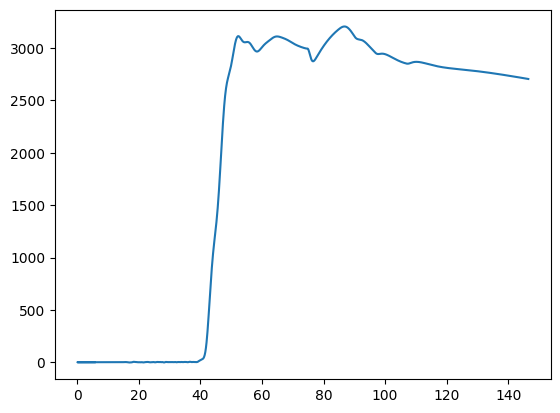

In [53]:
df_temp = myflight.df
plt.plot(df_temp["Time"], df_temp["ROC"])

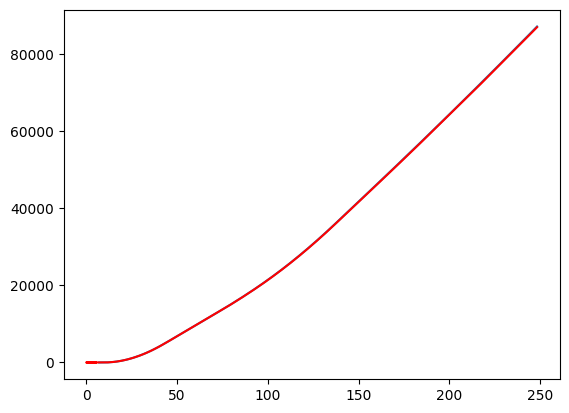

In [37]:
plt.plot(df_temp.iloc[20:]["Time"], df_temp.iloc[20:]["Distance_x"])
plt.plot(df_temp["Time"], df_temp["Distance"], "r")

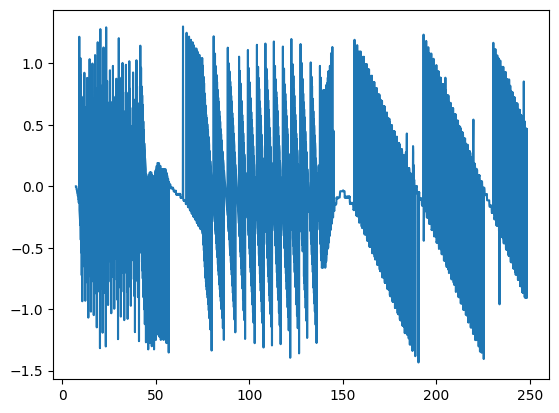

In [44]:
plt.plot(df_temp.iloc[21:]["Time"], np.diff(df_temp.iloc[20:]["Distance"])-np.diff(df_temp.iloc[20:]["Distance_x"]))

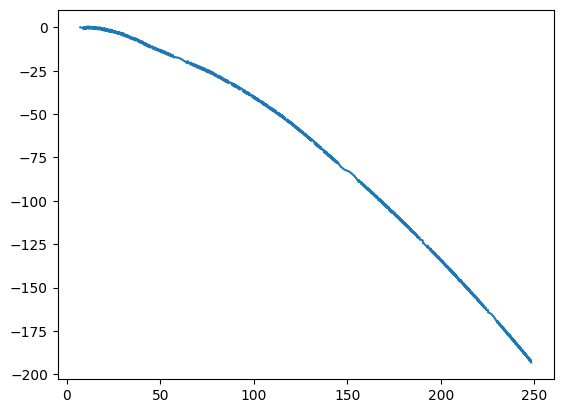

In [46]:
plt.plot(df_temp.iloc[20:]["Time"], df_temp.iloc[20:]["Distance"]-df_temp.iloc[20:]["Distance_x"])

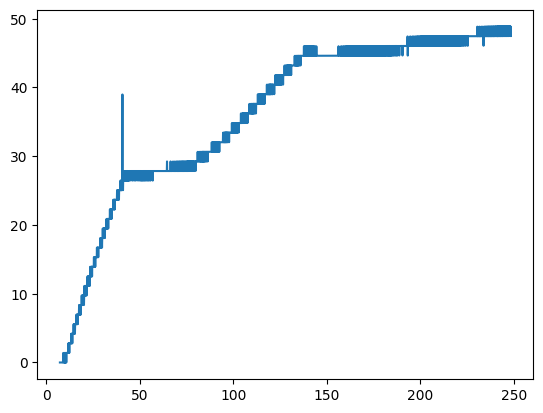

In [48]:
plt.plot(df_temp.iloc[21:]["Time"], np.diff(df_temp.iloc[20:]["Distance"]))

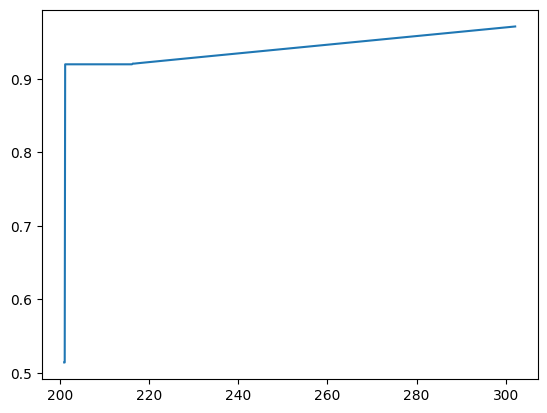

In [105]:
plt.plot(df_temp["Time"], df_temp["Throttle"])

In [88]:
df_temp.columns

Index(['Time', 'Distance', 'Altitude_Above_Ground', 'Latitude', 'Longitude',
       'Throttle', 'Thrust', 'Thrust_Corrected', 'Engine_N1', 'Engine_N2',
       'Ground_Speed', 'CAS', 'TAS', 'ROC', 'Flap_Stick', 'Flap_ID', 'theta',
       'delta', 'sigma', 'Alpha', 'vpath', 'hpath', 'Roll', 'Heading',
       'CL_overall', 'CD_overall', 'Wind_Speed', 'Wind_Direction',
       'Wind_dir_sin', 'Wind_dir_cos', 'Total_Weight', 'Flap_0', 'Flap_1',
       'Flap_5', 'Flap_10', 'Flap_15', 'Flap_25', 'Flap_30', 'Flap_40',
       'Altitude_MSL', 'X', 'Y', 'Side_Dist', 'Elevator', 'Aileron', 'Rudder',
       'cmd_vpath', 'T_amb', 'Pressure', 'Engine_Power', 'Runway_Condition',
       'Acceleration', 'Segment', 'vpath_desired', 'Flap_Changing'],
      dtype='object')

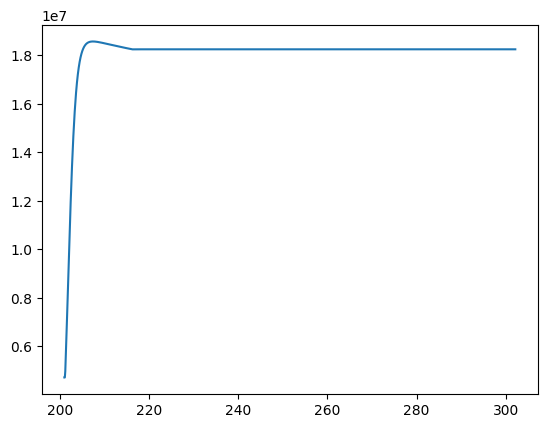

In [106]:
plt.plot(df_temp["Time"], df_temp["Engine_Power"])

# Reza Task

In [27]:
p1 = np.array([19208.95, -1246.7, 1411.09])
p2 = np.array([20554.35, -1874.1, 1486.21])
gamma = np.arctan((p2[2]-p1[2])/np.sqrt((p2[0]-p1[0])**2 + (p2[1]-p1[1])**2))

In [14]:
n = p2-p1
const = np.dot(n, p1)

In [18]:
pp1 = copy.copy(p1)
pp2 = copy.copy(p2)
pp1[2] = 0
pp2[2] = 0
l = pp2 - pp1

In [19]:
d = np.dot(p1-pp1, n)/np.dot(l, n)

In [20]:
R = pp1 + d*l

In [21]:
R

array([19273.66470183, -1276.87838853,     0.        ])

In [38]:
rotation_axis = np.cross(p1-R, p2-R)

In [22]:
import numpy as np
import math

def rotation_matrix(axis, theta):
    """
    Return the rotation matrix associated with counterclockwise rotation about
    the given axis by theta radians.
    """
    axis = np.asarray(axis)
    axis = axis / math.sqrt(np.dot(axis, axis))
    a = math.cos(theta / 2.0)
    b, c, d = -axis * math.sin(theta / 2.0)
    aa, bb, cc, dd = a * a, b * b, c * c, d * d
    bc, ad, ac, ab, bd, cd = b * c, a * d, a * c, a * b, b * d, c * d
    return np.array([[aa + bb - cc - dd, 2 * (bc + ad), 2 * (bd - ac)],
                     [2 * (bc - ad), aa + cc - bb - dd, 2 * (cd + ab)],
                     [2 * (bd + ac), 2 * (cd - ab), aa + dd - bb - cc]])

In [39]:
M_rotation = rotation_matrix(rotation_axis, gamma)

In [44]:
p1_rotated = np.dot(M_rotation,p1-R) + R
p2_rotated = np.dot(M_rotation,p2-R) + R

In [45]:
p1_rotated

array([19273.66470183, -1276.87838853,  1412.89550777])

In [46]:
p2_rotated

array([20620.78615839, -1905.08115488,  1412.89550777])